# CROPSENSE PROJECT



## 1. Librairies

This project needs libraries in order to work.
You will may need to install them by using `pip install tifffile imagecodecs numpy pandas pymongo matplotlib scipy opencv-python spectral scikit-learn --user` on your Terminal (type cmd on Windows)

In [1]:
import os
import gc
import shutil
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile as tiff
from datetime import datetime, timedelta
from pymongo import MongoClient
import gridfs
import spectral.io.envi as envi
from scipy.interpolate import make_interp_spline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## 2. Setup and annex functions

### 2.1 Setup

In [2]:
PATH_INBOX = "C:/CROPSENSE/INBOX"          # Inbox folder (Camera software output)
PATH_DATA_ROOT = "C:/CROPSENSE/CROPSENSE_DATA" # Hierarchical final storage
PATH_EXPORT = "C:/CROPSENSE/EXPORTED_FROM_DB" # Path where exported data from database will be stored
CSV_LOG_PATH = "./experience_log.csv"      # Ground Truth tracking file

# MongoDB Connection (Auto-switch Local/Server)
URIS_TO_TRY = ['172.20.10.8', 'localhost'] # Add your server IPs here
DB_NAME = 'cropsense_db'
COLLECTION_NAME = 'capture_events'

# Define SILIOS Wavelengths mapping for easier access
SILIOS_WAVELENGTHS = {
    0: "410nm", 1: "463nm", 2: "500nm", 3: "557nm", 4: "605nm",
    5: "666nm", 6: "693nm", 7: "756nm", 8: "807nm", 9: "869nm"
}


# SILIOS TOUCAN Demosaicing Matrix (Fixed Pattern)
# Source: TOUCAN Matrix Filter arrangement V1.0
TOUCAN_PATTERN = {
    0: [(0,3), (2,1)], 1: [(0,1), (2,3)], 2: [(2,0)], 3: [(0,0), (2,2)],
    4: [(1,2)], 5: [(3,0)], 6: [(1,0)], 7: [(1,3), (3,1)],
    8: [(1,1), (3,3)], 9: [(3,2)]
}

In [3]:
### NEW DATABASE IMPLEMENTATION SETUP

In [4]:
from datetime import datetime

def save_to_cropsense_db(db, fs, plant_id, timestamp, ms_data, thermal_data, hs_data):
    # 1. CREATE "ANCHOR" (CAPTURE EVENT)
    event_doc = {
        "sample_id": plant_id,
        "timestamp": timestamp,
        "capture_status": "complete",
        "ingested_at": datetime.utcnow()
    }
    event_id = db['capture_events'].insert_one(event_doc).inserted_id

    # 2. SAVE MULTISPECTRAL
    if ms_data:
        ms_gridfs_id = fs.put(ms_data['raw_tiff'], filename=ms_data['filename'])
        ms_doc = {
            "capture_event_id": event_id,
            "gridfs_ref": ms_gridfs_id,
            "captured_at": ms_data['captured_at'],
            "integration_time_ms": ms_data['integration_time_ms'],
            "ndvi": ms_data['ndvi'],
            "histogram_256": ms_data['histogram']
        }
        db['sensors_multispectral'].insert_one(ms_doc)

    # 3. SAVE THERMAL
    if thermal_data:
        thermal_gridfs_id = fs.put(thermal_data['raw_file'], filename=thermal_data['filename'])
        thermal_doc = {
            "capture_event_id": event_id,
            "gridfs_ref": thermal_gridfs_id,
            "captured_at": thermal_data['captured_at'],
            "ambient_temp_c": thermal_data['ambient_temp'],
            "max_leaf_temp_c": thermal_data['max_leaf_temp'],
            "cwsi": thermal_data['cwsi']
        }
        db['sensors_thermal'].insert_one(thermal_doc)

    # 4. SAVE HYPERSPECTRAL 
    if hs_data:
        hs_gridfs_id = fs.put(hs_data['raw_cube'], filename=hs_data['filename'])
        hs_doc = {
            "capture_event_id": event_id,
            "gridfs_ref": hs_gridfs_id,
            "captured_at": hs_data['captured_at'],
            "spectral_range_nm": hs_data['spectral_range'],
            "mean_signature": hs_data['mean_signature']
        }
        db['sensors_hyperspectral'].insert_one(hs_doc)
        
    print(f"Data successfully inserted into collections for Event: {event_id}")

### 2.2 Functions

#### 2.2.1 `get_mongo_client()`
This utility function implements a robust failover connection strategy for the database. It iterates through a predefined list of URI strings (typically `localhost` and the remote server IP) and attempts to establish a connection with a short timeout. It validates the connection by requesting server information; if successful, it returns the active MongoDB client object, ensuring the pipeline can operate seamlessly in both standalone and networked environments.

In [5]:
def get_mongo_client():
    """Attempts to connect to MongoDB using the provided list of URIs."""
    for uri in URIS_TO_TRY:
        print(f"Attempt to connect to MongoDB on {uri}")
        try:
            client = MongoClient(uri, 27017, serverSelectionTimeoutMS=2000)
            client.server_info() # Force connection check
            print(f"✅ Connected to MongoDB on {uri}")
            return client
        except:
            continue
    print("❌ Critical Error: No database accessible.")
    return None

#### 2.2.2 `parse_colorshades_manifest(txt_filepath)`
Designed to extract technical and scientific metadata, this function parses the auxiliary text files (`.txt`) generated by the Color Shades acquisition software. It reads the file content line by line to identify key parameters such as the camera serial number (Camera SN) and exposure time. Crucially, it also retrieves the calibrated filter wavelengths and channel normalization coefficients, ensuring that the subsequent spectral reconstruction adheres strictly to the specific radiometric calibration of the sensor.

In [6]:
def parse_colorshades_manifest(txt_filepath):
    """
    Parses the .txt manifest generated by Color Shades to extract technical metadata
    including real wavelengths and normalization coefficients.
    """
    meta = {
        "camera_sn": "Unknown", 
        "exposure": 1.0, 
        "wavelengths": [],    
        "coefficients": []    
    }
    
    if not os.path.exists(txt_filepath):
        return meta

    try:
        with open(txt_filepath, 'r') as f:
            content = f.readlines()
            
        for line in content:
            # Serial Number
            if "Camera SN" in line:
                meta["camera_sn"] = line.split(":")[-1].strip()
            
            # Exposure (remove " ms" unit)
            if "Exposure" in line:
                val = line.split(":")[-1].strip().replace(" ms", "")
                try: meta["exposure"] = float(val)
                except: pass
                
            # Real Wavelengths (e.g. 411, 463...)
            if "Filter's centering (nm)" in line:
                raw_vals = line.split(":")[-1].strip().split()
                meta["wavelengths"] = [int(x) for x in raw_vals]
                
            # Channel Coefficients
            if "Coefficients channel normalizer" in line:
                raw_vals = line.split(":")[-1].strip().split()
                meta["coefficients"] = [float(x) for x in raw_vals]
                
    except Exception as e:
        print(f"⚠️ Error reading manifest {os.path.basename(txt_filepath)}: {e}")
        
    return meta

#### 2.2.3 `organize_incoming_files()` 
This function acts as the ingestion engine of the pipeline. It scans the "`INBOX`" directory for raw files and uses Regular Expressions (Regex) to parse filenames, extracting the Plant ID and determining the sensor type (Spectral or Thermal). Based on the file creation timestamp and the extracted identifiers, it dynamically creates a hierarchical directory structure (`Date`/`PlantID`/`SensorType`) and moves the files from the temporary inbox to this permanent storage, effectively automating the data sorting process and filtering out irrelevant files like screenshots.

In [7]:
def organize_incoming_files():
    """
    Sorts files from INBOX into the hierarchy: DATA_ROOT / Date / Plant_ID / Sensor_Type
    Implements specific logic for prefixes 'Spectral', 'Multispectral', 'Thermal'.
    """
    print("\n--- 1. Sorting incoming files (INBOX) ---")
    if not os.path.exists(PATH_INBOX): 
        print(f"⚠️ Inbox directory not found: {PATH_INBOX}")
        return

    count = 0
    # Reserved keywords that cannot be Plant IDs
    RESERVED_KEYWORDS = ["SPECTRAL", "MULTISPECTRAL", "THERMAL"]

    for filename in os.listdir(PATH_INBOX):
        file_path = os.path.join(PATH_INBOX, filename)
        if os.path.isdir(file_path): continue

        # Init variables
        plant_id = "Unassigned"
        sensor_type = "Unclassified"
        filename_clean = filename.strip()
        
        # --- RULE 1: EXPLICIT PREFIX DETECTION ---
        # Check if file starts with specific keywords followed by a separator (e.g., "_")
        # Regex looks for: (Spectral|Thermal) _ (PotentialID) _ (Rest)
        match_explicit = re.match(r"^(Spectral|Multispectral|Thermal)_([a-zA-Z0-9]+)_(.*)", filename_clean, re.IGNORECASE)
        
        if match_explicit:
            type_str = match_explicit.group(1).upper()
            candidate_id = match_explicit.group(2)
            
            # 1.1 Determine Sensor Type
            if "THERMAL" in type_str:
                sensor_type = "Thermal"
            else:
                sensor_type = "Spectral"
                
            # 1.2 Validate Plant ID
            # Rule: Must not be a reserved word AND must start with a letter
            if candidate_id.upper() not in RESERVED_KEYWORDS and candidate_id[0].isalpha():
                plant_id = candidate_id
            else:
                plant_id = "Unassigned"
                
        else:
            # --- RULE 2: FALLBACK PATTERN DETECTION ---
            # If no explicit prefix, try to guess based on file structure
            
            # Case A: Thermal (Starts with digits like "00-10-12...")
            # Also checks for thermal keywords if the pattern matches
            if re.match(r"^(\d{2}-\d{2}-\d{2}-\d{3})", filename_clean):
                sensor_type = "Thermal"
                print(f"   [Ingestion] Pattern Detection used: Thermal Digit Pattern detected for {filename}")
                plant_id = "Unassigned" # Thermal files usually don't have the ID in the name here
                 
            # Case B: Spectral (Contains Date_Time pattern OR ends with specific extensions)
            elif re.search(r"_\d{8}_\d{6}_", filename_clean) or filename_clean.lower().endswith(('_raw.tiff', '.txt')):
                sensor_type = "Spectral"
                print(f"   [Ingestion] Pattern Detection used: Spectral Date/Time Pattern detected for {filename}")
                
                # Try to extract Plant ID from the start of the file
                # Split by first underscore
                parts = filename_clean.split('_')
                if len(parts) > 1:
                    candidate = parts[0]
                    # Same validation rules
                    if candidate.upper() not in RESERVED_KEYWORDS and candidate[0].isalpha():
                        plant_id = candidate
                    else:
                        plant_id = "Unassigned"

        print(f"   [Ingestion] File: {filename} -> Detected Type: {sensor_type}, Plant: {plant_id}")

        # --- PROCESSING & MOVING ---
        
        # Filter: Delete Thermal Screenshots
        if sensor_type == "Thermal" and "screenshot" in filename_clean.lower():
            try:
                os.remove(file_path)
                print(f"🗑️ Deleted screenshot: {filename}")
            except Exception as e:
                print(f"⚠️ Could not delete {filename}: {e}")
            continue
            
        # Move Valid Files
        if sensor_type != "Unclassified":
            try:
                timestamp = os.path.getmtime(file_path)
                date_folder = datetime.fromtimestamp(timestamp).strftime('%Y-%m-%d')
                
                # Target: DATA / Date / PlantID / SensorType
                target_dir = os.path.join(PATH_DATA_ROOT, date_folder, plant_id, sensor_type)
                os.makedirs(target_dir, exist_ok=True)
                
                target_path = os.path.join(target_dir, filename)
                if not os.path.exists(target_path):
                    shutil.move(file_path, target_path)
                    count += 1
                    print(f"📦 Moved: {filename} -> {plant_id}/{sensor_type}")
                else:
                    print(f"ℹ️ Skipped (Duplicate): {filename}")
            except Exception as e:
                print(f"❌ Error moving {filename}: {e}")
        else:
            print(f"⚠️ Skipped Unclassified file: {filename}")

    print(f"   -> {count} files successfully organized.")

#### 2.2.4 `process_spectral_image(filepath, manifest_meta)`
This function executes the core signal processing for multispectral data by reading raw `TIFF` images and applying a demosaicing algorithm based on the SILIOS TOUCAN 4x4 filter pattern to reconstruct a 10-band spectral cube. Crucially, it applies radiometric correction by normalizing the raw pixel intensity of each band using specific coefficients retrieved from the sensor's manifest file. Finally, it extracts features by generating an intensity histogram (`256 bins`) for each corrected wavelength (dynamically named based on the manifest, e.g., 411nm), packaging these analytics alongside the correction factors into a dictionary for database storage.

In [8]:
def process_spectral_image(filepath, manifest_meta):
    img_data = tiff.imread(filepath)
    h, w = img_data.shape
    print(f"   [Processing] Loaded Raw TIFF. Dimensions: {w}x{h} pixels.")
    new_h, new_w = h // 4, w // 4
    
    # Retrieve dynamic info from the text file
    # If the text file was missing, use default values
    real_wavelengths = manifest_meta.get("wavelengths")
    if not real_wavelengths or len(real_wavelengths) != 10:
        real_wavelengths = [411, 463, 500, 557, 606, 667, 694, 756, 808, 870] # Fallback
        
    coeffs = manifest_meta.get("coefficients")
    if not coeffs or len(coeffs) != 10:
        coeffs = [1.0] * 10 # No correction if file is missing
        
    cube = np.zeros((10, new_h, new_w), dtype=np.float32)
    analytics = {}
    print(f"   [Processing] Applied Normalization Coefficients: {coeffs}")
    
    for band_idx, coords in TOUCAN_PATTERN.items():
        # 1. Reconstruction (Demosaicing)
        stack = [img_data[r::4, c::4][:new_h, :new_w] for r, c in coords]
        raw_band = np.mean(stack, axis=0)
        
        # 2. Radiometric Correction (Applying the coefficient)
        # This is the crucial step: normalizing the intensity
        corrected_band = raw_band * coeffs[band_idx]
        
        # Store in the cube
        cube[band_idx] = corrected_band

        # 3. Histogram Calculation on the CORRECTED band
        # Use the real name (e.g., "411nm" not "410nm")
        band_name = f"{real_wavelengths[band_idx]}nm"
        
        # Round for the histogram because coefficients create decimals
        hist, _ = np.histogram(corrected_band.astype(np.uint16), bins=256)
        
        analytics[band_name] = {
            "histogram": hist.tolist(),
            "correction_factor": coeffs[band_idx] # Store the factor used
        }
        
    print(f"   [Processing] Signal Stats -> Min: {np.min(cube):.2f}, Max: {np.max(cube):.2f}, Mean: {np.mean(cube):.2f}")
    return {
        "camera_model": "SILIOS TOUCAN",
        "cube": cube,
        "camera_sn": manifest_meta.get("camera_sn", "Unknown"),
        "exposure_ms": manifest_meta.get("exposure"),
        "analytics": analytics
    }

#### 2.2.5 `find_thermal_cluster(spectral_path, tolerance=120)` 
To achieve sensor fusion, this function implements a temporal reconciliation algorithm. Using the timestamp of a processed spectral image as a reference anchor, it recursively scans the daily directory structure to locate 'Thermal' subfolders. It identifies files created within a defined tolerance window (e.g., ±300 seconds) and aggregates the four specific output files generated by the Workswell camera—Visual RGB, Radiometric JPEG, Raw Thermal TIFF, and CWSI TIFF—into a unified logical cluster, thereby linking asynchronous captures into a single event.

In [9]:
def find_thermal_cluster(spectral_path, plant_id, tolerance=300):
    """
    Finds the cluster of 4 Workswell thermal files corresponding to the spectral image timestamp, according to their ID.
    Searches in all 'Thermal' subfolders for the same date.
    """
    matches = {}
    spec_time = datetime.fromtimestamp(os.path.getmtime(spectral_path))
    
    # 1. Construct the specific target path
    # Structure: DATA / Date / PlantID / Spectral  --> We want DATA / Date / PlantID / Thermal
    spectral_folder = os.path.dirname(spectral_path)    # .../PlantID/Spectral
    plant_root = os.path.dirname(spectral_folder)       # .../PlantID
    target_thermal_dir = os.path.join(plant_root, "Thermal")
    
    # 2. Immediate exit if the folder doesn't exist for THIS plant
    if not os.path.exists(target_thermal_dir): 
        return matches

    # 3. Scan ONLY this specific directory
    for f in os.listdir(target_thermal_dir):
        f_path = os.path.join(target_thermal_dir, f)
        
        # Skip directories
        if os.path.isdir(f_path): continue
        
        # Check time
        therm_time = datetime.fromtimestamp(os.path.getmtime(f_path))
        
        if abs((spec_time - therm_time).total_seconds()) <= tolerance:
            if "visible" in f: matches["visual_rgb"] = f_path
            elif "radiometric" in f: matches["radiometric_jpg"] = f_path
            elif "thermo" in f: matches["raw_thermal_tiff"] = f_path
            elif "cwsi" in f: matches["cwsi_tiff"] = f_path
                    
    return matches

#### 2.2.6 `save_gridfs_file(fs, file_id, folder, default_name)`
An helper function to save a single file from GridFS.
It is used for example on `batch_export_all()`

In [10]:
def save_gridfs_file(fs, file_id, folder, default_name):
    """Helper function to save a single file from GridFS"""
    try:
        grid_out = fs.get(file_id)
        
        # Use the real filename if available in GridFS metadata
        if grid_out.filename:
            final_name = grid_out.filename
        else:
            final_name = default_name
            
        output_path = os.path.join(folder, final_name)
        
        # Skip if already exists
        if os.path.exists(output_path):
            return

        with open(output_path, 'wb') as f:
            f.write(grid_out.read())
            
    except Exception as e:
        print(f"      -> Failed to save file {file_id}: {e}")

#### 2.2.7 `process_independent_thermal(date_folder_path, db_collection, fs)`

This function acts as a comprehensive safety mechanism designed to ingest thermal datasets that were not temporally synchronized with spectral images during the main pipeline execution. By performing a secondary scan of the Thermal directories, it systematically identifies and groups isolated Workswell camera outputs—combining the Visible, Radiometric, Raw TIFF, and CWSI files into coherent acquisition events based on their shared timestamps. To maintain database integrity, the function performs a rigorous deduplication check against MongoDB, ensuring that only truly new data is processed. These independent events are then archived with a specific schema where the multispectral field is explicitly set to null, allowing researchers to easily query and distinguish standalone thermal experiments from multi-sensor data within the global dataset.

In [11]:
def process_independent_thermal(date_folder_path, db_collection, fs):
    """
    Scans for thermal files that were NOT linked to a spectral event and uploads them.
    No specific tag is added to the database; the spectral field will simply be Null.
    
    Args:
        date_folder_path (str): Path to the Date folder (e.g., .../2025-12-10/)
        db_collection: MongoDB collection object
        fs: GridFS object
    """
    print(f"\n🔄 [Independent Thermal] Scanning for standalone thermal data in {os.path.basename(date_folder_path)}...")
    
    count_new = 0
    
    # 1. Walk through all folders in this Date
    for root, dirs, files in os.walk(date_folder_path):
        folder_name = os.path.basename(root)
        
        # We only care about "Thermal" folders
        if folder_name != "Thermal":
            continue
            
        # Deduce Plant ID from parent folder (e.g. .../P01/Thermal -> P01)
        plant_id = os.path.basename(os.path.dirname(root))
        
        # 2. Group files by 'Shot' (Timestamp prefix)
        # Workswell files look like: "14-20-00-123-thermo.tiff"
        shots = {}
        
        for f in files:
            # Simple regex to capture the HH-MM-SS-mmm prefix
            match = re.match(r"^(\d{2}-\d{2}-\d{2}-\d{3})", f)
            if match:
                prefix = match.group(1)
                if prefix not in shots: shots[prefix] = {}
                
                full_path = os.path.join(root, f)
                
                # Assign type
                if "visible" in f: shots[prefix]["visual_rgb"] = full_path
                elif "radiometric" in f: shots[prefix]["radiometric_jpg"] = full_path
                elif "thermo" in f: shots[prefix]["raw_thermal_tiff"] = full_path
                elif "cwsi" in f: shots[prefix]["cwsi_tiff"] = full_path

        # 3. Process each shot
        for prefix, file_dict in shots.items():
            
            # CHECK: Does this thermal data already exist in DB?
            # We look for the filename in the 'sensor_thermal' section to avoid duplicates.
            if "raw_thermal_tiff" in file_dict:
                ref_filename = os.path.basename(file_dict["raw_thermal_tiff"])
                exists = db_collection.find_one({"sensor_thermal.original_filename": ref_filename})
                
                if exists:
                    # Already processed (either via Spectral Fusion or previously imported) -> Skip
                    continue
            
            # 4. If not in DB, it's a new Independent Event
            stored_files_ids = {}
            
            # Upload files to GridFS
            for f_type, f_path in file_dict.items():
                try:
                    with open(f_path, 'rb') as f_in:
                        # We upload to GridFS
                        fid = fs.put(f_in, filename=os.path.basename(f_path), content_type="image/tiff")
                        stored_files_ids[f_type] = fid
                except Exception as e:
                    print(f"   ⚠️ Error uploading {f_path}: {e}")

            # Create Database Document
            try:
                # Reconstruct timestamp from filename (HH-MM-SS-mmm) and Folder Date
                time_parts = prefix.split("-") # ['14', '20', '00', '123']
                date_str = os.path.basename(date_folder_path) # '2025-12-10'
                
                # Format: YYYY-MM-DD HH:MM:SS
                timestamp_str = f"{date_str} {time_parts[0]}:{time_parts[1]}:{time_parts[2]}"
                
                event_doc = {
                    "context": {
                        "plant_id": plant_id,
                        "timestamp": timestamp_str
                        # No 'mode' tag added here, keeping it clean.
                    },
                    "sensor_multispectral": None, # Explicitly Empty
                    "sensor_thermal": {
                        "camera_model": "WORKSWELL WIRIS AGRO R",
                        "original_filename": os.path.basename(file_dict.get("raw_thermal_tiff", "unknown")),
                        "files": stored_files_ids,
                        "detected_count": len(stored_files_ids)
                    }
                }
                
                db_collection.insert_one(event_doc)
                print(f"   ✅ Saved Thermal Event (No Spectral): {plant_id} @ {time_parts[0]}:{time_parts[1]}")
                count_new += 1
                
            except Exception as e:
                print(f"   ❌ Error saving doc: {e}")

    print(f"   -> Added {count_new} new independent thermal events.")

## 3. Main functions

#### 3.1 `run_pipeline()`
This is the main orchestrator function that executes the full ETL (Extract, Transform, Load) workflow. It sequentially triggers the file organization, establishes the database connection, and iterates through the structured dataset. For every valid spectral image found, it coordinates the processing (via `process_spectral_image`), the fusion (via `find_thermal_cluster`), and the construction of the final JSON document. Finally, it handles the upload of binary files to MongoDB's GridFS and the insertion of the structured document into the collection.

#### ⚠️ RUN IT ONLY WHEN YOUR DATA IS CLEAN ⚠️

### 3.2 `rename_batch_prefix(folder_path, old_prefix, new_prefix)`
This function batch renames all files in a folder that start with an old prefix, replacing that start with a new prefix.
Useful when the files saved are prenamed by the camera or the sofware output, and you want to change the name of all the file you just used, or you want to solve a mistake.

In [12]:
def rename_batch_prefix(folder_path, old_prefix, new_prefix):
    """
    Batch renames all files in a folder that start with 'old_prefix',
    replacing that start with 'new_prefix'.
    
    Example: 
    rename_batch_prefix("C:/INBOX", "hbda", "PLANT1")
    will transform "hbda.0001.tiff" into "PLANT1.0001.tiff"
    """
    
    # 1. Folder verification
    if not os.path.exists(folder_path):
        print(f"❌ Folder does not exist: {folder_path}")
        return

    print(f"🔄 Renaming in progress in {folder_path}...")
    print(f"   Replacing '{old_prefix}' with '{new_prefix}'")
    
    count = 0
    errors = 0

    # 2. Iterate through files
    for filename in os.listdir(folder_path):
        # Process only files starting with the old prefix
        if filename.startswith(old_prefix):
            
            # Construct the new filename
            # Cut the "old_prefix" part and paste "new_prefix" at the start
            suffix = filename[len(old_prefix):] # The rest of the name (e.g., ".0001.tiff")
            new_filename = new_prefix + suffix
            
            old_path = os.path.join(folder_path, filename)
            new_path = os.path.join(folder_path, new_filename)
            
            try:
                # Safety check: do not overwrite if the file already exists
                if os.path.exists(new_path):
                    print(f"⚠️ Skipped (Already exists): {new_filename}")
                    errors += 1
                    continue
                
                # Actual renaming
                os.rename(old_path, new_path)
                print(f"✅ {filename} -> {new_filename}")
                count += 1
                
            except Exception as e:
                print(f"❌ Error on {filename}: {e}")
                errors += 1

    print(f"\n--- Finished: {count} files renamed ({errors} errors) ---")

### 3.3 `export_file_from_db(output_folder, plant_id, sensor_type, thermal_file_type, mongo_uri, db_name)`
This function retrieves a multispectral file from a MongoDB database and saves it to a specified output folder on the local disk. By default, it fetches the most recent image recorded in the database; however, if a specific `plant_id` is provided, the search is filtered to retrieve the last image associated with that plant. The connection is established using the provided mongo_uri (defaulting to '`localhost`') and db_name. If `sensor_type` equals to `spectral`, `thermal_file_type` has no use. However, if `sensor_type` equals to `thermal`, `thermal_file_type` allows to choose between `visual_rgb`, `radiometric.jpg`, `raw_thermal_tiff`, and `cwsi_tiff`. Upon completion, the function returns the absolute path of the saved file, or `None` if the operation fails.

In [13]:
# --- HELPER FUNCTION ---
def sanitize_for_mongo(data):
    if isinstance(data, dict):
        return {k: sanitize_for_mongo(v) for k, v in data.items()}
    elif isinstance(data, list):
        return [sanitize_for_mongo(v) for v in data]
    elif isinstance(data, np.ndarray):
        if data.size > 1000:
            return f"Excluded ndarray of shape {data.shape} to save space"
        return data.tolist()
    elif isinstance(data, np.generic): 
        return data.item()
    return data



def get_or_create_capture_event(db, sample_id, timestamp):
    """
    Implements the 10-Minute Synchronization Window logic.
    Finds an existing event within +/- 10 mins, or creates a new one.
    """
    events_coll = db["capture_events"]
    
    # 10-minute window window boundary
    start_time = timestamp - timedelta(minutes=10)
    end_time = timestamp + timedelta(minutes=10)
    
    # Check if an event already exists for this plant in that timeframe
    existing_event = events_coll.find_one({
        "sample_id": sample_id,
        "timestamp": {"$gte": start_time, "$lte": end_time}
    })
    
    if existing_event:
        return existing_event["_id"]
    
    # If not, create a new central hub event
    new_event = {
        "sample_id": sample_id,
        "timestamp": timestamp,
        "capture_status": "complete", 
        "ingested_at": datetime.utcnow()
    }
    result = events_coll.insert_one(new_event)
    return result.inserted_id


# --- MAIN PIPELINE FUNCTION ---
def run_pipeline():
    # A. Ingestion (Organization)
    organize_incoming_files()
    
    # B. Database Connection
    client = get_mongo_client()
    if not client: return
    
    db = client[DB_NAME]
    fs = gridfs.GridFS(db)

    print("\n--- 2. Scientific Processing ---")
    
    for root, dirs, files in os.walk(PATH_DATA_ROOT):
        if os.path.basename(root) not in ["Spectral", "Hyperspectral", "Thermal"]: continue
        
        manifest_meta = {}
        txt_files = [f for f in files if f.endswith(".txt")]
        if txt_files:
            manifest_meta = parse_colorshades_manifest(os.path.join(root, txt_files[0]))

        for file in files:
            
            # =========================================================================
            # HYPERSPECTRAL BLOCK (.hdr / .raw)
            # =========================================================================
            if file.endswith(".hdr") and "DARKREF" not in file and "WHITEREF" not in file:
                
                if db["sensors_hyperspectral"].count_documents({"filename": file}) > 0:
                    continue

                print(f"⚙️ Processing Hyperspectral: {file}")
                filepath = os.path.join(root, file)
                
                try:
                    plant_id = os.path.basename(os.path.dirname(root)) 
                    timestamp = datetime.fromtimestamp(os.path.getmtime(filepath))
                    
                    fichiers_dark = glob.glob(os.path.join(root, "*DARKREF*.hdr"))
                    fichiers_white = glob.glob(os.path.join(root, "*WHITEREF*.hdr"))
                    
                    if fichiers_dark and fichiers_white:
                        specim_meta = prepare_hyperspectral_data(filepath, fichiers_dark[0], fichiers_white[0])
                        if specim_meta is None: continue
                            
                        raw_filepath = filepath.replace(".hdr", ".raw")
                        if not os.path.exists(raw_filepath): raw_filepath = filepath.replace(".hdr", ".img")
                            
                        print(f"   [Storage] Uploading Hyperspectral cube to GridFS...")
                        with open(raw_filepath, 'rb') as f:
                            cube_file_id = fs.put(f, filename=os.path.basename(raw_filepath))
                        
                        # 🟢 1. Link to or create the Central Capture Event
                        event_id = get_or_create_capture_event(db, plant_id, timestamp)
                        
                        # 🟢 2. Build the specific Hyperspectral Document
                        hs_doc = {
                            "capture_event_id": event_id,
                            "gridfs_ref": cube_file_id, 
                            "captured_at": timestamp,
                            "filename": file,
                            "spectral_range_nm": specim_meta.get("wavelengths", []),
                            "mean_signature": specim_meta.get("mean", [])
                        }
                        
                        db["sensors_hyperspectral"].insert_one(sanitize_for_mongo(hs_doc))
                        print(f"✅ [Success] Hyperspectral linked to Event ID: {event_id}")
                        
                except Exception as e:
                    print(f"   ❌ Error processing hyperspectral {file}: {e}")

            # =========================================================================
            # MULTISPECTRAL & THERMAL BLOCK (.tiff)
            # =========================================================================
            elif file.endswith("_raw.tiff"):
                
                if db["sensors_multispectral"].count_documents({"filename": file}) > 0:
                    continue

                print(f"⚙️ Processing Multispectral: {file}")
                filepath = os.path.join(root, file)
                
                try:
                    plant_id = os.path.basename(os.path.dirname(root)) 
                    timestamp = datetime.fromtimestamp(os.path.getmtime(filepath))
                    
                    raw_spec_data = process_spectral_image(filepath, manifest_meta)
                    spec_data = sanitize_for_mongo(raw_spec_data)
                    
                    thermal_files = find_thermal_cluster(filepath, plant_id=plant_id)
                    thermal_files_ids = []
                    
                    print(f"   [Storage] Uploading files to GridFS...")
                    with open(filepath, 'rb') as f:
                        ms_file_id = fs.put(f, filename=file)
                    
                    for key, t_path in thermal_files.items():
                        with open(t_path, 'rb') as f:
                            thermal_files_ids.append(fs.put(f, filename=os.path.basename(t_path)))

                    # 🟢 1. Link to or create the Central Capture Event
                    # 🟢 1. Link to or create the Central Capture Event
                    event_id = get_or_create_capture_event(db, plant_id, timestamp)

                    # 🟢 2. Build and insert the Multispectral Document (Strict PDF Schema)
                    # On suppose que 'spec_data' contient 'ndvi' et 'histogram'
                    ms_doc = {
                        "capture_event_id": event_id,
                        "gridfs_ref": ms_file_id,
                        "captured_at": timestamp,
                        "filename": file,
                        "integration_time_ms": manifest_meta.get('exposure', None),
                        "ndvi": spec_data.get('ndvi', None), # Extrait de ton dictionnaire
                        "histogram_256": spec_data.get('histogram_256', []) # Extrait de ton dictionnaire
                    }
                    db["sensors_multispectral"].insert_one(sanitize_for_mongo(ms_doc))
                    
                    # 🟢 3. Build and insert the Thermal Document
                    if thermal_files:
                        th_doc = {
                            "capture_event_id": event_id,
                            "gridfs_ref": thermal_files_ids,
                            "captured_at": timestamp,
                            # Ajout des champs demandés par le PDF. 
                            # Si tu n'as pas encore la fonction pour les lire, on met None.
                            "ambient_temp_c": None, 
                            "max_leaf_temp_c": None,
                            "cwsi": None 
                        }
                        db["sensors_thermal"].insert_one(sanitize_for_mongo(th_doc))

                    # 🟢 4. INITIALISATION ML_ANALYSIS (Optionnel mais recommandé)
                    # Crée une entrée "pending" pour que ton modèle IA sache qu'il y a du travail !
                    if db["ml_analysis"].count_documents({"capture_event_id": event_id}) == 0:
                        ml_doc = {
                            "capture_event_id": event_id,
                            "health_status": "pending",
                            "confidence_scores_decision_tree": None,
                            "confidence_scores_logistic_reg": None,
                            "confidence_scores_neural_net": None,
                            "analyzed_at": None
                        }
                        db["ml_analysis"].insert_one(ml_doc)

                    print(f"✅ [Success] MS/Thermal & ML Init linked to Event ID: {event_id}")

                except Exception as e:
                    print(f"   ❌ Error processing {file}: {e}")
            # =========================================================================
            # INDEPENDENT THERMAL BLOCK
            # =========================================================================
            # Catch thermal files (adjust the extension if your Workswell uses .jpg or .csv)
            # =========================================================================
            # INDEPENDENT THERMAL BLOCK
            # =========================================================================
            # 🟢 FIX: .lower() makes it case-insensitive to catch .TIFF, .TIF, or .tiff
            elif file.lower().endswith((".tiff", ".tif")) and not file.endswith("_raw.tiff") and "spectral" not in file.lower():
                
                # Anti-Duplicate Check
                if db["sensors_thermal"].count_documents({"filename": file}) > 0:
                    continue

                print(f"⚙️ Processing Independent Thermal: {file}")
                filepath = os.path.join(root, file)
                
                try:
                    plant_id = os.path.basename(os.path.dirname(root)) 
                    timestamp = datetime.fromtimestamp(os.path.getmtime(filepath))
                    
                    print(f"   [Storage] Uploading Thermal file to GridFS...")
                    with open(filepath, 'rb') as f:
                        t_file_id = fs.put(f, filename=file)

                    # 1. Link to or create the Central Capture Event 
                    event_id = get_or_create_capture_event(db, plant_id, timestamp)

                    # 2. Build and insert the Thermal Document
                    th_doc = {
                        "capture_event_id": event_id,
                        "gridfs_ref": [t_file_id], 
                        "captured_at": timestamp,
                        "filename": file,          
                        "camera_model": "WORKSWELL WIRIS AGRO R",
                        "ambient_temp_c": None,
                        "max_leaf_temp_c": None,
                        "cwsi": None 
                    }
                    db["sensors_thermal"].insert_one(sanitize_for_mongo(th_doc))

                    # 3. INITIALISATION ML_ANALYSIS
                    if db["ml_analysis"].count_documents({"capture_event_id": event_id}) == 0:
                        ml_doc = {
                            "capture_event_id": event_id,
                            "health_status": "pending",
                            "confidence_scores_decision_tree": None,
                            "confidence_scores_logistic_reg": None,
                            "confidence_scores_neural_net": None,
                            "analyzed_at": None
                        }
                        db["ml_analysis"].insert_one(ml_doc)

                    print(f"✅ [Success] Independent Thermal linked to Event ID: {event_id}")

                except Exception as e:
                    print(f"   ❌ Error processing thermal {file}: {e}")
                    
    print("\n✅ Pipeline execution complete.")

In [14]:
def export_file_from_db(output_folder, plant_id=None, sensor_type='spectral', thermal_file_type='radiometric_jpg', mongo_uri='localhost', db_name='cropsense_db'):
    """
    Retrieves a file (Spectral OR Thermal) from MongoDB and saves it to disk.
    
    Parameters:
    - output_folder (str): Destination folder.
    - plant_id (str, optional): ID of the plant (e.g., "P01"). If None, takes the latest event.
    - sensor_type (str): 'spectral' OR 'thermal'.
    - thermal_file_type (str): Only if sensor_type='thermal'. 
                               Options: 'visual_rgb', 'radiometric_jpg', 'raw_thermal_tiff', 'cwsi_tiff'.
    """
    
    # 1. Connect to DB
    try:
        client = MongoClient(mongo_uri, 27017, serverSelectionTimeoutMS=2000)
        db = client[db_name]
        fs = gridfs.GridFS(db)
        coll = db['capture_events']
        client.server_info()
    except Exception as e:
        print(f"❌ Connection Error: {e}")
        return None

    # 2. Find Event
    query = {}
    if plant_id:
        query["context.plant_id"] = plant_id
        print(f"🔍 Searching last event for plant: {plant_id}...")
    else:
        print("🔍 Searching for the very last event recorded...")

    event = coll.find_one(query, sort=[("context.timestamp", -1)])
    if not event:
        print("⚠️ No event found.")
        return None

    # 3. Identify File ID based on request
    file_id = None
    original_filename = "unknown_file"

    try:
        if sensor_type == 'spectral':
            # Get the main TIFF file
            data_node = event.get('sensor_multispectral', {})
            file_id = data_node.get('raw_file_id')
            original_filename = data_node.get('filename', 'spectral.tif')
            
        elif sensor_type == 'thermal':
            # Get one of the 4 thermal files
            files_node = event.get('sensor_thermal', {}).get('files', {})
            
            # Map the user request to the database keys.
            # Keys are stored as plain names (e.g. "radiometric_jpg"), NOT with _id suffix.
            db_key = thermal_file_type  # e.g. "radiometric_jpg"
            
            file_id = files_node.get(db_key)
            
            # We try to reconstruct a name (since it wasn't explicitly stored in the simplified node)
            # But GridFS knows the name! We will get it later.
            original_filename = f"thermal_{thermal_file_type}.img" 

        # 4. Download and Save
        if not file_id:
            print(f"⚠️ No file found for sensor '{sensor_type}' (Type: {thermal_file_type}) in this event.")
            return None

        if not os.path.exists(output_folder):
            os.makedirs(output_folder)

        # Retrieve from GridFS
        grid_out = fs.get(file_id)
        data = grid_out.read()
        
        # Use the real filename stored in GridFS if possible
        if grid_out.filename:
            original_filename = grid_out.filename
            
        output_path = os.path.join(output_folder, original_filename)
        
        with open(output_path, 'wb') as f:
            f.write(data)
            
        print(f"✅ File saved: {output_path}")
        print(f"   (Source: {sensor_type} | Date: {event['context']['timestamp']})")
        return output_path

    except Exception as e:
        print(f"❌ Error during extraction: {e}")
        return None

### 3.4 `batch_export_all()`
This function is a mass extraction tool designed to reconstruct your entire physical dataset from the MongoDB database. It begins by establishing a connection to the server and retrieving all recorded event documents, then iterates through each entry to extract contextual metadata (plant identifier and date). 

Using this information, it dynamically recreates a structured folder hierarchy on your hard drive (e.g., `EXPORT/P01/2025-11-25`) and queries the GridFS system to download and write the original binary files (spectral TIFF and thermal images) back into their respective folders, thereby ensuring a comprehensive backup or data transfer to a standard file system.

In [15]:
def batch_export_all():
    print(f"🚀 Starting Batch Export to: {EXPORT_ROOT}")
    
    # 1. Connection
    try:
        client = MongoClient(MONGO_URI, 27017, serverSelectionTimeoutMS=2000)
        db = client[DB_NAME]
        fs = gridfs.GridFS(db)
        coll = db['capture_events']
        client.server_info()
    except Exception as e:
        print(f"❌ Connection Error: {e}")
        return

    # 2. Get ALL events
    # You can add a filter here, e.g., {"context.plant_id": "P01"}
    cursor = coll.find({}) 
    total_docs = coll.count_documents({})
    
    print(f"📦 Found {total_docs} events to process...")

    count = 0
    for doc in cursor:
        try:
            # 3. Context Info
            context = doc.get('context', {})
            plant_id = context.get('plant_id', 'Unknown')
            # Safe timestamp handling
            ts = context.get('timestamp')
            if isinstance(ts, str): # If stored as string
                date_str = ts[:10] # YYYY-MM-DD
            elif isinstance(ts, datetime): # If stored as Date object
                date_str = ts.strftime('%Y-%m-%d')
            else:
                date_str = "NoDate"

            # 4. Create Target Folder
            # Structure: EXPORT / PlantID / Date
            target_folder = os.path.join(EXPORT_ROOT, plant_id, date_str)
            if not os.path.exists(target_folder):
                os.makedirs(target_folder)

            # 5. Export Spectral File
            spec_node = doc.get('sensor_multispectral', {})
            spec_id = spec_node.get('raw_file_id')
            if spec_id:
                filename = spec_node.get('filename', f"spectral_{plant_id}.tif")
                save_gridfs_file(fs, spec_id, target_folder, filename)

            # 6. Export Thermal Files
            therm_node = doc.get('sensor_thermal', {}).get('files', {})
            for file_type, file_id in therm_node.items():
                # file_type is like "radiometric_jpg_id"
                # We construct a name if the original isn't stored, or get it from GridFS
                filename = f"thermal_{file_type}.img" 
                save_gridfs_file(fs, file_id, target_folder, filename)

            count += 1
            print(f"   [{count}/{total_docs}] Processed {plant_id} ({date_str})")

        except Exception as e:
            print(f"   ❌ Error processing doc {doc.get('_id')}: {e}")

    print("\n✅ Batch Export Completed.")

### 3.5 `export_recent_files(output_folder, limit, plant_id, sensor_type, thermal_file_type, mongo_uri, db_name)`

This function retrieves the most recent batch of images from the database and saves them to the specified `output_folder`. The number of retrieved files is controlled by the limit parameter (defaulting to 5), and the query can be optionally filtered by a specific `plant_id` or left open to include all plants. The function requires defining the `sensor_type` as either '`spectral`' or '`thermal`'; if '`thermal`' is selected, the specific file format (such as '`visual_rgb`' or '`radiometric_jpg`') must be designated using the `thermal_file_type` argument.

In [16]:
def export_recent_files(output_folder, limit=5, plant_id=None, sensor_type='spectral', thermal_file_type='radiometric_jpg', mongo_uri='localhost', db_name='cropsense_db'):
    """
    Retrieves the last 'n' images recorded in the database.
    
    Parameters:
    - output_folder (str): Folder where files will be saved.
    - limit (int): Number of files to retrieve (default 5).
    - plant_id (str, optional): Filter by plant (e.g., "P01"). If None, takes all plants.
    - sensor_type (str): 'spectral' OR 'thermal'.
    - thermal_file_type (str): If thermal, which file? ('visual_rgb', 'radiometric_jpg', etc.)
    """
    
    # 1. Connection
    try:
        client = MongoClient(mongo_uri, 27017, serverSelectionTimeoutMS=2000)
        db = client[db_name]
        fs = gridfs.GridFS(db)
        coll = db['capture_events']
        client.server_info()
    except Exception as e:
        print(f"❌ Connection Error: {e}")
        return

    # 2. Query Configuration
    query = {}
    if plant_id:
        query["context.plant_id"] = plant_id
        print(f"🔍 Searching for the last {limit} images for plant: {plant_id}...")
    else:
        print(f"🔍 Searching for the last {limit} images (all plants)...")

    # 3. Retrieve cursor (Sorted by date DESC)
    # .limit(limit) restricts the number of results
    cursor = coll.find(query).sort("context.timestamp", -1).limit(limit)
    
    count = 0
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 4. Loop through results
    for event in cursor:
        try:
            # -- Same logic as the single function to find the ID --
            file_id = None
            filename_prefix = ""

            if sensor_type == 'spectral':
                data_node = event.get('sensor_multispectral', {})
                file_id = data_node.get('raw_file_id')
                # We add the timestamp to the name to avoid duplicates if filenames are identical
                ts_str = event['context']['timestamp'].strftime("%H%M%S")
                original_name = data_node.get('filename', 'spec.tif')
                
            elif sensor_type == 'thermal':
                files_node = event.get('sensor_thermal', {}).get('files', {})
                db_key = f"{thermal_file_type}_id"
                file_id = files_node.get(db_key)
                ts_str = event['context']['timestamp'].strftime("%H%M%S")
                original_name = f"thermal_{thermal_file_type}.img"

            # -- Download --
            if file_id:
                grid_out = fs.get(file_id)
                # If GridFS has the real name, use it, otherwise use the constructed one
                final_name = grid_out.filename if grid_out.filename else original_name
                
                # Security: To avoid overwriting, we can prefix with the plant ID
                p_id = event['context']['plant_id']
                save_name = f"{p_id}_{final_name}"
                
                output_path = os.path.join(output_folder, save_name)
                
                with open(output_path, 'wb') as f:
                    f.write(grid_out.read())
                
                print(f"   ✅ [{count+1}/{limit}] Saved: {save_name}")
                count += 1
            else:
                print(f"   ⚠️ Event found but no file for this sensor (Plant: {event['context']['plant_id']})")

        except Exception as e:
            print(f"   ❌ Error on a file: {e}")

    print(f"🚀 Completed. {count} files exported to {output_folder}")

### 3.6 `check_database_integrity(plant_id_to_check, mongo_uri, db_name)`

In [17]:
def check_database_integrity(plant_id_to_check, mongo_uri='localhost', db_name='cropsense_db'):
    """
    Diagnose function to verify if files for a specific plant are correctly stored in GridFS.
    
    Args:
        plant_id_to_check (str): The Plant ID to look for (e.g., "FirstTests", "PO1").
        mongo_uri (str): Address of the MongoDB server.
    """
    print(f"\n🔍 --- DIAGNOSIS FOR PLANT: {plant_id_to_check} ---")
    
    # 1. Connection
    try:
        client = MongoClient(mongo_uri, 27017, serverSelectionTimeoutMS=2000)
        db = client[db_name]
        fs = gridfs.GridFS(db)
        coll = db['capture_events']
        client.server_info() # Check connection
    except Exception as e:
        print(f"❌ Connection Failed: {e}")
        return

    # 2. General Stats
    total_files = db['fs.files'].count_documents({})
    print(f"📦 Total binary files in GridFS (All plants): {total_files}")

    # 3. Find the Document
    # We look for the most recent event for this plant
    event = coll.find_one({"context.plant_id": plant_id_to_check}, sort=[("context.timestamp", -1)])

    if not event:
        print(f"❌ No metadata document found for plant '{plant_id_to_check}'.")
        print("   -> Check if the Plant ID is correct (Case sensitive!).")
        return

    print(f"✅ Metadata document found (Date: {event['context']['timestamp']})")

    # 4. Check Spectral File
    print("\n   [Spectral Sensor]")
    spec_id = event.get('sensor_multispectral', {}).get('raw_file_id')
    if spec_id:
        if fs.exists(spec_id):
            file_meta = fs.get(spec_id)
            print(f"     ✅ RAW TIFF exists (Size: {file_meta.length / 1024 / 1024:.2f} MB)")
        else:
            print(f"     ❌ ERROR: File ID exists in document but file is missing in GridFS!")
    else:
        print("     ⚠️ No Spectral file linked.")

    # 5. Check Thermal Files
    print("\n   [Thermal Sensor]")
    thermal_files = event.get('sensor_thermal', {}).get('files', {})
    
    if not thermal_files:
        print("     ⚠️ No Thermal files linked (Empty list).")
    else:
        for file_type, file_id in thermal_files.items():
            if fs.exists(file_id):
                file_meta = fs.get(file_id)
                print(f"     ✅ {file_type}: OK (Size: {file_meta.length / 1024:.2f} KB)")
            else:
                print(f"     ❌ {file_type}: Missing body in GridFS (ID: {file_id})")

### 3.7 `show_spectral_channel(filepath, channel_index, wavelength)`

This visualization utility is designed to permit granular inspection of the multispectral data. It provides a flexible interface allowing users to query a specific spectral band either by its index (0-9) or its physical wavelength (e.g., '756nm'). The function automatically adapts to the input file format: for pre-processed spectral stacks (3D arrays), it extracts the corresponding slice, while for raw sensor mosaics (2D arrays), it executes an on-the-fly demosaicing process to reconstruct the specific band image based on the sensor's filter matrix. The resulting radiometric data is then rendered as a high-contrast color-mapped heatmap using Matplotlib, facilitating the visual assessment of pixel intensity distributions across the leaf surface.

In [18]:
def show_spectral_channel(filepath, channel_index=None, wavelength=None, interpolation='bicubic'):
    """
    Displays a specific channel from a SILIOS multispectral TIFF file.
    
    Parameters:
    - filepath (str): Path to the .tiff file (Raw Mosaic or Stack).
    - channel_index (int): Index of the band (0 to 9, or 0 to 125).
    - wavelength (str/int): Wavelength to find (e.g., 557 or "557nm"). 
                            Overrides channel_index if provided.
    """
    
# 1. Resolve Channel Index from Wavelength
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    # 1. Charger l'image D'ABORD pour connaître sa structure
    try:
        img_data = tiff.imread(filepath)
    except Exception as e:
        print(f"❌ Error reading file: {e}")
        return

    is_125_bands = (img_data.ndim == 3 and img_data.shape[2] == 125)

    # 2. Résoudre le channel_index si une longueur d'onde est fournie
    if wavelength is not None:
        target_wl = float(str(wavelength).replace("nm", "").strip())
        
        if is_125_bands:
            # Formule inversée : Index = (Wavelength - 450) / (500 / 124)
            step = 500 / 124
            calculated_idx = int(round((target_wl - 450) / step))
            channel_index = max(0, min(124, calculated_idx)) # Garder entre 0 et 124
            print(f"🔍 Wavelength {target_wl}nm correspond to channel index {channel_index}")
        else:
            # Logique d'origine pour SILIOS (10 bandes)
            found = False
            for idx, name in SILIOS_WAVELENGTHS.items():
                if str(int(target_wl)) in name:
                    channel_index = idx
                    found = True
                    break
            if not found:
                print(f"❌ Wavelength '{wavelength}' not found in SILIOS.")
                return

    if channel_index is None:
        print("❌ Invalid channel index.")
        return

    # 3. Extraction de l'image
    band_image = None
    if is_125_bands:
        band_image = img_data[:, :, channel_index]
        mode = "External Stack (125 Bands)"
        # Calcul de la longueur d'onde exacte pour l'affichage
        wl_display = f"{450 + channel_index * (500 / 124):.1f} nm"
        
    elif img_data.ndim == 3 and img_data.shape[0] < img_data.shape[1]:
        band_image = img_data[channel_index]
        mode = "Processed Stack (Silios)"
        wl_display = SILIOS_WAVELENGTHS.get(channel_index, f"Canal {channel_index}")
        
    elif img_data.ndim == 2:
        if channel_index not in TOUCAN_PATTERN: return
        h, w = img_data.shape
        new_h, new_w = h // 4, w // 4
        stack = [img_data[r::4, c::4][:new_h, :new_w] for r, c in TOUCAN_PATTERN[channel_index]]
        band_image = np.mean(stack, axis=0)
        mode = "Raw Mosaic (Silios)"
        wl_display = SILIOS_WAVELENGTHS.get(channel_index, f"Canal {channel_index}")

    # 4. Affichage
    plt.figure(figsize=(8, 8))
    plt.title(f"Spectral Image: {wl_display}\nMode: {mode}")
    img_plot = plt.imshow(band_image, cmap='inferno', interpolation=interpolation) # Lissage ajouté ici !
    plt.colorbar(img_plot, label="Pixel Intensity")
    plt.axis('off') 
    plt.show()
 

In [19]:
def show_spectral_image(filepath, r_wl=650, g_wl=550, b_wl=450, r_idx=None, g_idx=None, b_idx=None, interpolation='bicubic'):
    """
    Affiche une composition RGB (vraies couleurs) depuis un fichier TIFF multispectral.
    
    Parameters:
    - r_wl, g_wl, b_wl : Longueurs d'ondes cibles pour le Rouge, Vert, Bleu.
    - r_idx, g_idx, b_idx : Permet de forcer des index de canaux spécifiques si besoin.
    """
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    # 1. Charger l'image D'ABORD pour connaître sa structure
    try:
        img_data = tiff.imread(filepath)
    except Exception as e:
        print(f"❌ Error reading file: {e}")
        return

    is_125_bands = (img_data.ndim == 3 and img_data.shape[2] == 125)

    # 2. Fonction utilitaire pour trouver l'index exact d'une longueur d'onde
    def get_channel_index(target_wl, fallback_idx):
        if is_125_bands:
            # Formule pour le dataset 450-950nm
            step = 500 / 124
            calculated_idx = int(round((target_wl - 450) / step))
            return max(0, min(124, calculated_idx))
        else:
            # Recherche dans le dictionnaire SILIOS
            for idx, name in SILIOS_WAVELENGTHS.items():
                if str(int(target_wl)) in name:
                    return idx
            return fallback_idx # Si non trouvé, on utilise l'index de secours

    # Résolution des 3 canaux (on utilise des index de secours au cas où pour SILIOS)
    idx_R = r_idx if r_idx is not None else get_channel_index(r_wl, fallback_idx=5)
    idx_G = g_idx if g_idx is not None else get_channel_index(g_wl, fallback_idx=3)
    idx_B = b_idx if b_idx is not None else get_channel_index(b_wl, fallback_idx=1)

    print(f"🔍 RGB Composé avec les canaux - R:{idx_R}, G:{idx_G}, B:{idx_B}")

    # 3. Fonction pour extraire un canal spécifique selon le format
    def extract_band(channel_index):
        if is_125_bands:
            return img_data[:, :, channel_index]
        elif img_data.ndim == 3 and img_data.shape[0] < img_data.shape[1]:
            return img_data[channel_index]
        elif img_data.ndim == 2:
            if channel_index not in TOUCAN_PATTERN: 
                return np.zeros((img_data.shape[0]//4, img_data.shape[1]//4))
            h, w = img_data.shape
            stack = [img_data[r::4, c::4][:h//4, :w//4] for r, c in TOUCAN_PATTERN[channel_index]]
            return np.mean(stack, axis=0)
        return None

    # Extraction des 3 matrices 2D
    band_R = extract_band(idx_R)
    band_G = extract_band(idx_G)
    band_B = extract_band(idx_B)

    if band_R is None or band_G is None or band_B is None:
        print("❌ Erreur lors de l'extraction des canaux.")
        return

    # 4. Superposition et Normalisation
    # On empile les 3 matrices pour faire un cube (H, W, 3) compatible RGB
    rgb_image = np.dstack((band_R, band_G, band_B))
    
    # La normalisation "intelligente" (Percentile 2% - 98%)
    # Évite que l'image soit gâchée par un seul pixel brillant ou trop sombre
    p2, p98 = np.percentile(rgb_image, (2, 98))
    rgb_normalized = np.clip((rgb_image - p2) / (p98 - p2), 0, 1)

    mode = "External Stack (125 Bands)" if is_125_bands else ("Raw Mosaic (Silios)" if img_data.ndim == 2 else "Processed Stack (Silios)")

    # 5. Affichage
    plt.figure(figsize=(8, 8))
    plt.title(f"RGB True Color Composite\nMode: {mode} | Wavelengths ~ {r_wl}nm, {g_wl}nm, {b_wl}nm")
    
    # Pas de cmap='inferno' ici, car on affiche une vraie image RGB couleur !
    plt.imshow(rgb_normalized, interpolation=interpolation)
    plt.axis('off') 
    plt.show()

### 3.8 `show_thermal_image(filepath)`
This visualization utility is specifically designed to render single-channel radiometric data produced by the Workswell WIRIS camera. Unlike standard image viewers which often display raw 16-bit thermal data as undefined black pixels, this function maps the raw scalar values (Temperature or Crop Water Stress Index) to a perceptually uniform color palette (e.g., 'Magma' for temperature, 'Red-Yellow-Green' for `CWSI`). Beyond simple visualization, it computes and prints key descriptive statistics—minimum, maximum, and mean values—providing immediate quantitative insight into the thermal dynamics of the plant sample directly from the raw file.

In [20]:
def show_thermal_image(filepath):
    """
    Displays a thermal image (Raw TIFF or CWSI) with a color scale.
    Also prints statistics (Min, Max, Mean) of the temperature/index.
    
    Parameters:
    - filepath (str): Path to the .tiff file (e.g., '..._thermo.tiff' or '..._cwsi.tiff')
    """
    
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    try:
        # 1. Read Image
        # For thermal, it's a simple 2D image (1 channel), not a cube.
        img_data = tiff.imread(filepath)
        
        # 2. Detect Type (Temperature or CWSI)
        filename = os.path.basename(filepath).lower()
        
        if "cwsi" in filename:
            # CWSI is an index between 0 and 1 (or 0-100%)
            label_unit = "CWSI Index (Water Stress)"
            cmap_choice = "RdYlGn_r" # Red = High Stress, Green = Healthy
        else:
            # Raw Thermo
            label_unit = "Raw Value (Temperature)"
            cmap_choice = "magma" # Black/Purple = Cold, Orange/Yellow = Hot
            
        # 3. Calculate Statistics
        val_min = np.min(img_data)
        val_max = np.max(img_data)
        val_avg = np.mean(img_data)
        
        print(f"📊 Statistics for {filename}:")
        print(f"   🔹 Min: {val_min:.2f}")
        print(f"   🔸 Max: {val_max:.2f}")
        print(f"   sz Mean: {val_avg:.2f}")

        # 4. Graphical Display
        plt.figure(figsize=(10, 8))
        plt.title(f"Thermal Analysis: {filename}")
        
        # Display with false colors
        img_plot = plt.imshow(img_data, cmap=cmap_choice)
        
        # Side Colorbar
        cbar = plt.colorbar(img_plot)
        cbar.set_label(label_unit, rotation=270, labelpad=15)
        
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"❌ Error during display: {e}")

#### 3.9 `plot_image_histogram(filepath, band_index, bins, log_scale)`

This visualization utility is designed for the granular inspection of radiometric distribution within a single data channel. It features a polymorphic interface that automatically adapts to the input file type: for 3D multispectral cubes, it extracts and analyzes a specific wavelength band defined by the user (e.g., Band 7 - Red Edge), whereas for 2D thermal matrices, it processes the entire array. The function renders a frequency histogram of pixel intensities and overlays key statistical indicators—specifically the mean and median values—allowing the operator to rapidly assess exposure quality and detect potential sensor saturation or underexposure in specific spectral or thermal regions.

In [21]:
def plot_image_histogram(filepath, band_index=None, bins=100, log_scale=False):
    """
    Displays the pixel intensity distribution histogram for a given image.
    Handles both Spectral images (selectable band) and Thermal images.
    
    Parameters:
    - filepath (str): Path to the .tiff file.
    - band_index (int, optional): Band index (0-9) for spectral files. Ignored for thermal.
    - bins (int): Number of bars in the histogram (default 100).
    - log_scale (bool): If True, uses a logarithmic scale (useful if background dominates).
    """
    
    
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    try:
        img_data = tiff.imread(filepath)
        data_to_plot = None
        title_suffix = ""
        color = 'gray'

        # --- CASE 1: PROCESSED 3D CUBE (Bands, H, W) ---
        if img_data.ndim == 3 and img_data.shape[0] < img_data.shape[1]:
            if band_index is None: band_index = 0
            if band_index >= img_data.shape[0]:
                print(f"❌ Invalid band index ({band_index}).")
                return

            data_to_plot = img_data[band_index].flatten()
            wl = SILIOS_WAVELENGTHS.get(band_index, f"Band {band_index}")
            title_suffix = f"- Spectral {wl} (Processed)"
            color = 'purple'

        # --- CASE 1.5: EXTERNAL DATASET (H, W, Bands) ---
        elif img_data.ndim == 3 and img_data.shape[2] > 1:
            if band_index is None: band_index = 0
            if band_index >= img_data.shape[2]:
                print(f"❌ Invalid band index ({band_index}).")
                return
            
            data_to_plot = img_data[:, :, band_index].flatten()
            wl = SILIOS_WAVELENGTHS.get(band_index, f"Band {band_index}")
            title_suffix = f"- Spectral {wl} (External Data)"
            color = 'purple'

        # --- CASE 2: RAW 2D MOSAIC OR THERMAL ---
        elif img_data.ndim == 2:
            if "thermo" in filepath.lower() or "cwsi" in filepath.lower():
                data_to_plot = img_data.flatten()
                title_suffix = "- Thermal Data"
                color = 'orange'
            elif band_index is not None:
                if band_index not in TOUCAN_PATTERN:
                    print("❌ Error: Invalid band index for RAW Mosaic")
                    return
                r_off = band_index // 4
                c_off = band_index % 4
                data_to_plot = img_data[r_off::4, c_off::4].flatten()
                wl = SILIOS_WAVELENGTHS.get(band_index, f"Band {band_index}")
                title_suffix = f"- Spectral {wl} (Extracted from RAW)"
                color = 'blue'
            else:
                data_to_plot = img_data.flatten()
                title_suffix = "- Full Raw Mosaic (Mixed)"
                color = 'black'
        else:
            print(f"❌ Unrecognized format with shape: {img_data.shape}")
            return

        plt.figure(figsize=(10, 6))
        mean_val = np.mean(data_to_plot)
        median_val = np.median(data_to_plot)
        
        plt.hist(data_to_plot, bins=bins, color=color, alpha=0.7, log=log_scale, edgecolor='black', linewidth=0.5)
        plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
        plt.axvline(median_val, color='yellow', linestyle='dotted', linewidth=1.5, label=f'Median: {median_val:.2f}')
        
        plt.title(f"Histogram: {os.path.basename(filepath)}\n{title_suffix}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"❌ Error calculating histogram: {e}")

#### 3.10 `plot_full_spectral_histogram(filepath, mode, bins, log_scale)`

Developed for a holistic assessment of multispectral data quality, this function processes the entire 10-band spectral cube simultaneously. It operates in two distinct modes to suit different analytical needs: the 'Overlay' mode plots ten distinct distribution curves on a single set of axes, enabling immediate comparative analysis of sensor response across different wavelengths (essential for identifying dead bands or inconsistent gain settings). Alternatively, the 'Global' mode aggregates pixel data from all channels into a single cumulative histogram, providing a macro-view of the image's overall dynamic range usage. This tool is critical for validating that the camera integration settings are appropriate for the current lighting conditions before further processing.

In [22]:
def plot_full_spectral_histogram(filepath, mode='overlay', bins=100, log_scale=False):
    """
    Plots the histogram for the ENTIRE multispectral image.
    
    Parameters:
    - filepath (str): Path to the 10-band spectral TIFF.
    - mode (str): 
        'overlay' = Plots 10 separate lines (one per band) on the same graph.
        'global'  = Aggregates all pixels into one single histogram.
    - bins (int): Number of bins.
    - log_scale (bool): Logarithmic Y-axis.
    """
    
    if not os.path.exists(filepath):
        print(f"❌ File not found: {filepath}")
        return

    try:
        img_data = tiff.imread(filepath)
        plt.figure(figsize=(12, 7))
        title_mode = ""
        
        # --- CASE 1: SPECTRAL CUBE (Both Internal & External) ---
        if img_data.ndim == 3:
            is_external = img_data.shape[2] > 1 and img_data.shape[2] > img_data.shape[0]
            num_bands = img_data.shape[2] if is_external else img_data.shape[0]
            
            if mode == 'overlay':
                print(f"📊 Plotting overlay of {num_bands} spectral bands...")
                cmap = plt.get_cmap('tab20')
                for i in range(num_bands):
                    wl = SILIOS_WAVELENGTHS.get(i, f"Band {i}")
                    band_pixels = img_data[:, :, i].flatten() if is_external else img_data[i].flatten()
                    
                    plt.hist(band_pixels, bins=bins, histtype='step', linewidth=1.5,
                             label=f"{wl}", color=cmap(i % 20), log=log_scale)
                
                # Limiter la légende si le nombre de bandes est immense (ex: 125)
                if num_bands <= 20:
                    plt.legend(loc='upper right', fontsize='small', ncol=2)
                title_mode = "Per-Band Analysis (Processed Cube)"
                
            else:
                print("📊 Plotting global distribution (3D Cube)...")
                plt.hist(img_data.flatten(), bins=bins, color='gray', alpha=0.8, log=log_scale, label="All Bands")
                title_mode = "Global Distribution (Processed Cube)"

        # --- CASE 2: RAW MOSAIC or THERMAL (2D) ---
        elif img_data.ndim == 2:
            print("📊 Plotting Global Raw Histogram.")
            plt.hist(img_data.flatten(), bins=bins, color='black', alpha=0.7, log=log_scale, label="Raw Pixels")
            max_val = np.max(img_data)
            plt.axvline(max_val, color='red', linestyle='--', label=f'Max Detected: {max_val}')
            title_mode = "Raw Sensor Distribution (Global)"
            plt.legend()
        else:
            print(f"❌ Error: Unrecognized image shape {img_data.shape}")
            return

        plt.title(f"{title_mode}\n{os.path.basename(filepath)}")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency (Log)" if log_scale else "Frequency")
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
        print(f"❌ Error calculating histogram: {e}")

#### 3.11 `plot_spectral_profile(filepath)`

This function generates a Spectral Signature curve, effectively summarizing the average reflectance characteristics of the imaged subject across the ten discrete channels of the Silios CMS4 sensor. Unlike a standard frequency histogram, this tool maps specific wavelengths (in nanometers) on the X-axis against the mean pixel intensity on the Y-axis, allowing for a direct visualization of the spectral response profile. The function features an adaptive data processing logic that accommodates both raw 2D sensor mosaics—performing real-time pixel extraction to isolate channel data—and fully reconstructed 3D spectral cubes. This visualization is critical for identifying dominant spectral features, such as the characteristic "Green Peak" (557nm) or the sharp rise in the "Red Edge" (756nm+) typical of healthy vegetation biomass.

In [23]:
def plot_spectral_profile(filepath, smooth=True):
    """
    Plots the Spectral Signature with optional smoothing (Interpolation).
    
    Parameters:
    - filepath: Path to image
    - smooth: If True, draws a curved line. If False, draws straight lines.
    """
    
   
    if not os.path.exists(filepath):
        return

    try:
        img_data = tiff.imread(filepath)
        y_real = []
        x_real = []
        
        is_125_bands = (img_data.ndim == 3 and img_data.shape[2] == 125)
        is_external = img_data.ndim == 3 and img_data.shape[2] > 1 and img_data.shape[2] > img_data.shape[0]
        num_bands = img_data.shape[2] if is_external else (img_data.shape[0] if img_data.ndim == 3 else 10)

        # 1. Extraction des intensités (Y) et calcul des longueurs d'onde (X)
        for i in range(num_bands):
            if is_external:
                y_real.append(np.mean(img_data[:, :, i]))
            elif img_data.ndim == 3:
                y_real.append(np.mean(img_data[i]))
            else: # Raw mosaic 2D
                r_off, c_off = i // 4, i % 4
                y_real.append(np.mean(img_data[r_off::4, c_off::4]))
            
            # Calcul de l'axe X
            if is_125_bands:
                x_real.append(450 + i * (500 / 124))
            else:
                wl_str = SILIOS_WAVELENGTHS.get(i, str(400 + i*5)).replace("nm", "")
                x_real.append(float(wl_str))

        y_real = np.array(y_real)
        x_real = np.array(x_real)

        # 2. Lissage (Smoothing)
        x_smooth, y_smooth = x_real, y_real
        if smooth and len(x_real) > 3:
            x_smooth = np.linspace(x_real.min(), x_real.max(), 300)
            from scipy.interpolate import make_interp_spline
            spline = make_interp_spline(x_real, y_real, k=3) 
            y_smooth = spline(x_smooth)

        # 3. Affichage
        plt.figure(figsize=(10, 6))
        plt.plot(x_smooth, y_smooth, color='teal', linewidth=2.5, label='Interpolated Profile')
        # Pour 125 points, on réduit la taille des marqueurs pour que ce soit lisible
        marker_size = 15 if is_125_bands else 50
        plt.scatter(x_real, y_real, color='red', s=marker_size, zorder=5, label='Measured Bands')
        
        plt.title(f"Spectral Signature\n{os.path.basename(filepath)}")
        plt.xlabel("Wavelength (nm)")
        plt.ylabel("Mean Intensity")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    except Exception as e:
        print(f"❌ Error: {e}")

In [24]:
def prepare_hyperspectral_data(raw_hdr_path, dark_hdr_path, white_hdr_path, background='darken', min_brightness=0.03, max_brightness=0.85, ndvi_threshold=-0.1):
    """
    Version optimisée pour la MÉMOIRE (RAM) et la RAPIDITÉ.
    Empêche les crashs Jupyter sur les gros fichiers de 224 bandes.
    """
    print("⏳ [1/4] Chargement des références (Optimisation RAM)...")
    
    # 1. Chargement et purge immédiate des références pour libérer la RAM
    dark_img = envi.open(dark_hdr_path)
    dark_cube = np.array(dark_img[:, :, :], dtype=np.float32)
    dark_profile = np.mean(dark_cube, axis=0)
    del dark_cube  # Détruit le cube noir de la mémoire
    gc.collect()   # Force le nettoyage
    
    white_img = envi.open(white_hdr_path)
    white_cube = np.array(white_img[:, :, :], dtype=np.float32)
    white_profile = np.mean(white_cube, axis=0)
    del white_cube # Détruit le cube blanc de la mémoire
    gc.collect()

    # Dénominateur pour la calibration
    denominator = (white_profile - dark_profile)
    denominator[denominator == 0] = 1e-6
    
    
    print("⏳ [2/4] Chargement du fichier RAW et Calibration In-Place...")
    # 2. On charge l'image principale en forçant un format léger (float32)
    raw_img = envi.open(raw_hdr_path)
    reflectance_cube = np.array(raw_img[:, :, :], dtype=np.float32)
    
    # OPÉRATIONS "IN-PLACE" : Modifie le tableau existant (économise ~3 Go de RAM !)
    reflectance_cube -= dark_profile
    reflectance_cube /= denominator
    np.clip(reflectance_cube, 0, 1, out=reflectance_cube)
    
    print("🌿 [3/4] Création du masque...")
    
    try:
        wavelengths = np.array(raw_img.metadata['wavelength'], dtype=float)
        xlabel = "Wavelength (nm)"
        band_nir = (np.abs(wavelengths - 840.0)).argmin()
        band_red = (np.abs(wavelengths - 650.0)).argmin()
        idx_vis_start = (np.abs(wavelengths - 400.0)).argmin()
        idx_vis_end = (np.abs(wavelengths - 700.0)).argmin()
    except KeyError:
        wavelengths = np.arange(reflectance_cube.shape[2])
        xlabel = "Spectral Band Number"
        band_nir, band_red = 162, 95
        idx_vis_start, idx_vis_end = 0, 110 
        
    # --- MASQUES LÉGERS ---
    brightness_visible = np.mean(reflectance_cube[:, :, idx_vis_start:idx_vis_end], axis=2)
    masque_luminosite = (brightness_visible > min_brightness) & (brightness_visible < max_brightness)
    del brightness_visible # Nettoyage
    
    band_nir_data = reflectance_cube[:, :, band_nir]
    band_red_data = reflectance_cube[:, :, band_red]
    ndvi = (band_nir_data - band_red_data) / (band_nir_data + band_red_data + 1e-6)
    masque_ndvi = ndvi > ndvi_threshold 
    del band_nir_data, band_red_data, ndvi # Nettoyage
    
    masque_plante = masque_luminosite & masque_ndvi
    del masque_luminosite, masque_ndvi
    
    pixels_plante = reflectance_cube[masque_plante]
    if len(pixels_plante) == 0:
        print("⚠️ Aucune plante détectée. Ajustez les seuils.")
        return None

    print("📊 [4/4] Extraction des signatures et Préparation visuelle...")
    spectre_moyen = np.mean(pixels_plante, axis=0)
    spectre_std = np.std(pixels_plante, axis=0)

    rgb_image = reflectance_cube[:, :, [110, 70, 30]].copy()
    min_val = np.percentile(rgb_image, 2)
    max_val = np.percentile(rgb_image, 98)
    rgb_image = np.clip((rgb_image - min_val) / (max_val - min_val), 0, 1)

    if background == 'darken':
        
        rgb_image[~masque_plante] = rgb_image[~masque_plante] * 0.15
    elif background == 'purple':
        rgb_image[~masque_plante] = [0.6, 0.0, 0.8]
        
    rgb_final = np.rot90(rgb_image, k=1)

    print("✅ Données prêtes !")
    
    return {
        "rgb": rgb_final,
        "wavelengths": wavelengths,
        "mean": spectre_moyen,
        "std": spectre_std,
        "xlabel": xlabel,
        "cube": reflectance_cube, # Maintenant 2x plus léger !
        "masque": masque_plante
    }

In [25]:
def separate_data(donnees, ligne_coupe):
    """
    Sépare un jeu de données hyperspectrales en deux le long de l'axe de balayage (lignes).
    Recalcule les spectres moyens et les images RGB pour chaque partie.
    """
    if donnees is None:
        print("⚠️ Aucune donnée à séparer.")
        return None, None

    print(f"✂️ Découpage du cube à la ligne {ligne_coupe}...")

    # Récupération des données du dictionnaire
    cube_complet = donnees["cube"]
    masque_complet = donnees["masque"]
    wavelengths = donnees["wavelengths"]
    xlabel = donnees.get("xlabel", "Longueur d'onde (nm)")
    
    # L'image RGB qui a DÉJÀ votre fond (elle est actuellement tournée à 90°)
    rgb_complet_tourne = donnees["rgb"] 

    # 1. On annule temporairement la rotation (k=-1) pour l'aligner avec le cube et le masque
    rgb_complet = np.rot90(rgb_complet_tourne, k=-1)

    # ==========================================
    # SET 1 : Du début (0) jusqu'à la ligne_coupe
    # ==========================================
    cube_1 = cube_complet[:ligne_coupe, :, :]
    masque_1 = masque_complet[:ligne_coupe, :]
    rgb_1 = rgb_complet[:ligne_coupe, :, :]
    
    # On retourne le morceau obtenu (k=1) pour l'affichage final
    rgb_final_1 = np.rot90(rgb_1, k=1)

    # Recalcul des spectres (uniquement sur les pixels de la plante 1)
    pixels_1 = cube_1[masque_1]
    moyen_1 = np.mean(pixels_1, axis=0) if len(pixels_1) > 0 else np.zeros_like(wavelengths)
    std_1 = np.std(pixels_1, axis=0) if len(pixels_1) > 0 else np.zeros_like(wavelengths)

    donnees_1 = {
        "cube": cube_1,
        "masque": masque_1,
        "rgb": rgb_final_1,
        "wavelengths": wavelengths,
        "mean": moyen_1,
        "std": std_1,
        "xlabel": xlabel
    }

    # ==========================================
    # SET 2 : De la ligne_coupe jusqu'à la fin
    # ==========================================
    cube_2 = cube_complet[ligne_coupe:, :, :]
    masque_2 = masque_complet[ligne_coupe:, :]
    rgb_2 = rgb_complet[ligne_coupe:, :, :]
    
    # On retourne le morceau obtenu (k=1) pour l'affichage final
    rgb_final_2 = np.rot90(rgb_2, k=1)

    # Recalcul des spectres (uniquement sur les pixels de la plante 2)
    pixels_2 = cube_2[masque_2]
    moyen_2 = np.mean(pixels_2, axis=0) if len(pixels_2) > 0 else np.zeros_like(wavelengths)
    std_2 = np.std(pixels_2, axis=0) if len(pixels_2) > 0 else np.zeros_like(wavelengths)

    donnees_2 = {
        "cube": cube_2,
        "masque": masque_2,
        "rgb": rgb_final_2,
        "wavelengths": wavelengths,
        "mean": moyen_2,
        "std": std_2,
        "xlabel": xlabel
    }
    print("✅ Découpage terminé ! Deux sets de données créés.")
    return donnees_1, donnees_2

In [26]:
def show_hyperspectral_image(donnees):
    """ Displays only the segmented RGB image. """
    if donnees is None: return
    
    plt.figure(figsize=(8, 8))
    plt.imshow(donnees["rgb"])
    plt.title("Segmented plant (Darkened background)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [27]:
def show_hyperspectral_graph(donnees):
    """Displays only the reflectance curve and the markers."""
    if donnees is None: return
    
    plt.figure(figsize=(10, 6))
    
    # Récupération des données du dictionnaire
    wl = donnees["wavelengths"]
    mean = donnees["mean"]
    std = donnees["std"]
    
    # Les repères verticaux
    reperes = {
        480: ['blue', 'Blue (480nm)'],
        550: ['green', 'Green (550nm)'],
        650: ['red', 'Red (650nm)'],
        740: ['orange', 'Red Edge (740nm)'],
        833: ['purple', 'NIR (833nm)']
    }

    for x_val, (couleur, nom) in reperes.items():
        if np.min(wl) <= x_val <= np.max(wl):
            plt.axvline(x=x_val, color=couleur, linestyle='--', linewidth=1.5, alpha=0.8, label=nom)

    # Tracé de la courbe et de l'écart-type
    plt.plot(wl, mean, color='black', linewidth=2.5, label='Mean', zorder=5)
    plt.fill_between(wl, np.maximum(0, mean - std), mean + std, color='gray', alpha=0.3, label='Variability', zorder=4)
    
    plt.title("Average Spectral Profile of the Plant")
    plt.xlabel(donnees["xlabel"])
    plt.ylabel("Reflectance (0 to 1)")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [28]:
def show_multiple_hyperspectral_graphs(liste_donnees, labels=None, afficher_std=True):
    """
    Affiche plusieurs courbes de réflectance sur le même graphique.
    
    Paramètres :
    - liste_donnees : Une liste contenant vos dictionnaires (ex: [set_haut, set_bas])
    - labels : (Optionnel) Une liste de noms pour la légende (ex: ["Plante Haut", "Plante Bas"])
    - afficher_std : (Optionnel) True pour montrer la variabilité, False pour alléger le graphique
    """
    # Nettoyage de la liste (on enlève les potentiels 'None' si une séparation a échoué)
    donnees_valides = [d for d in liste_donnees if d is not None]
    
    if not donnees_valides:
        print("⚠️ No valid data to show")
        return

    plt.figure(figsize=(12, 7))
    
    # 1. Tracé des repères verticaux (On le fait une seule fois en utilisant le premier set)
    wl_ref = donnees_valides[0]["wavelengths"]
    reperes = {
        480: ['blue', 'Bleu (480nm)'],
        550: ['green', 'Vert (550nm)'],
        650: ['red', 'Rouge (650nm)'],
        740: ['orange', 'Red Edge (740nm)'],
        833: ['purple', 'NIR (833nm)']
    }

    for x_val, (couleur, nom) in reperes.items():
        if np.min(wl_ref) <= x_val <= np.max(wl_ref):
            # zorder=1 met ces lignes tout au fond du graphique
            plt.axvline(x=x_val, color=couleur, linestyle='--', linewidth=1.5, alpha=0.5, label=nom, zorder=1)

    # 2. Palette de couleurs robustes pour bien distinguer les courbes
    couleurs_courbes = ['black', '#1f77b4', '#d62728', '#9467bd', '#8c564b', '#e377c2']

    # 3. Boucle sur toutes les données envoyées
    for i, donnees in enumerate(donnees_valides):
        wl = donnees["wavelengths"]
        mean = donnees["mean"]
        std = donnees["std"]
        
        # Définition du nom dans la légende
        nom_label = labels[i] if labels and i < len(labels) else f"Plante {i+1}"
        couleur_actuelle = couleurs_courbes[i % len(couleurs_courbes)]

        # Tracé de la moyenne
        plt.plot(wl, mean, color=couleur_actuelle, linewidth=2.5, label=nom_label, zorder=5)
        
        # Tracé de l'écart-type (plus transparent qu'avant pour supporter la superposition)
        if afficher_std:
            plt.fill_between(wl, np.maximum(0, mean - std), mean + std, 
                             color=couleur_actuelle, alpha=0.15, zorder=4)

    # 4. Mise en forme finale
    plt.title("Spectral Profile Comparison")
    plt.xlabel(donnees_valides[0]["xlabel"])
    plt.ylabel("Reflectance (0 to 1)")
    
    # Organiser la légende pour ne pas cacher les données
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title="Legend", borderaxespad=0.)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [29]:
def compare_plants_indices(liste_donnees, labels=None):
    """
    Calcule tous les indices spectraux pour une liste de plantes 
    et renvoie un tableau comparatif (Pandas DataFrame).
    """
    # On filtre les données non valides (ex: si une séparation a échoué)
    donnees_valides = [d for d in liste_donnees if d is not None]
    
    if not donnees_valides:
        print("⚠️ No data available.")
        return None

    # Dictionnaire qui va stocker les colonnes de notre tableau
    resultats = {}

    for i, donnees in enumerate(donnees_valides):
        # Définition du nom de la colonne (Plante 1, Plante 2, ou le nom personnalisé)
        nom_colonne = labels[i] if labels and i < len(labels) else f"Plante {i+1}"
        
        # On calcule tous les indices en gérant le cas où une plante est vide (masque vide)
        try:
            # Assurez-vous d'avoir bien importé/défini toutes vos fonctions de calcul avant !
            indices = {
                "NDVI (800/670)": calculate_mean_ndvi(donnees, cible_nir=800, cible_red=670),
                "GNDVI": calculate_mean_gndvi(donnees),
                "RVI": calculate_mean_rvi(donnees),
                "WI": calculate_mean_wi(donnees),
                "NDWI": calculate_mean_ndwi(donnees),
                "SIPI": calculate_mean_sipi(donnees),
                "PRI": calculate_mean_pri(donnees),
                "ARI": calculate_mean_ari(donnees),
                "CARI": calculate_mean_cari(donnees)
            }
        except NameError as e:
            print(f"❌ Erreur : L'une de vos fonctions de calcul est manquante ({e})")
            return None

        # On ajoute les résultats de cette plante dans notre dictionnaire global
        resultats[nom_colonne] = indices

    # ---------------------------------------------------------
    # Création et formatage du tableau Pandas
    # ---------------------------------------------------------
    df = pd.DataFrame(resultats)
    
    # On arrondit tout à 5 décimales pour que ce soit propre
    df = df.round(5)
    
    # On ajoute un nom à la colonne des indices
    df.index.name = "Health Indices"
    
    return df

In [30]:
def explain_spectral_index(index_name="ALL"):
    """
    Helper function to explain Vegetative/Spectral Indices (VIs) with disease intervals.
    """
    
    indices_db = {
        "NDVI": {
            "name": "Normalized Difference Vegetation Index",
            "formula": "(R800 - R670) / (R800 + R670)",
            "purpose": "Estimates vegetation coverage based on chlorophyll content.",
            "values": {
                "Healthy Wheat": "0.75 to 0.90",
                "Yellow Rust": "0.40 to 0.65 (Chlorosis reduces NIR reflection & increases Red reflection)",
                "Septoria (STB)": "0.30 to 0.60 (Severe necrosis destroys chlorophyll rapidly)"
            }
        },
        "GNDVI": {
            "name": "Green Normalized Difference Vegetation Index",
            "formula": "(NIR - GREEN) / (NIR + GREEN)",
            "purpose": "Measures nitrogen content and identifies withered crops.",
            "values": {
                "Healthy Wheat": "0.65 to 0.85",
                "Diseased (General)": "< 0.50 (More sensitive to early chlorophyll loss than NDVI)"
            }
        },
        "RVI": {
            "name": "Ratio Vegetation Index",
            "formula": "R800 / R670",
            "purpose": "Estimates plant biomass.",
            "values": {
                "Healthy Wheat": "4.0 to 8.0+",
                "Yellow Rust / STB": "1.5 to 3.0 (Correlates strongly with loss of green biomass)"
            }
        },
        "WI": {
            "name": "Water Index",
            "formula": "R900 / R970",
            "purpose": "Evaluates water stress in plants.",
            "values": {
                "Healthy Wheat": "0.95 to 1.05",
                "Septoria (STB)": "Drops < 0.90 (STB causes rapid water loss in necrotic lesions)"
            }
       },
        "NDWI": {
            "name": "Normalized Difference Water Index",
            "formula": "(Gao, 1996) usually (NIR - SWIR) / (NIR + SWIR)",
            "purpose": "Evaluates leaf water content, crucial for STB.",
            "values": {
                "Healthy Wheat": "0.20 to 0.40",
                "Septoria (STB)": "-0.10 to 0.10 (Strong indicator of tissue drying from STB)"
            }
        },
        "SIPI": {
            "name": "Structure Insensitive Pigment Index",
            "formula": "(R800 - R445) / (R800 - R680)",
            "purpose": "Estimates the ratio of carotenoids to chlorophyll.",
            "values": {
                "Healthy Wheat": "0.80 to 0.95",
                "Yellow Rust": "1.0 to 1.2+ (Increases as chlorophyll degrades but carotenoids remain)"
            }
        },
        "PRI": {
            "name": "Photochemical Reflectance Index",
            "formula": "(R531 - R570) / (R531 + R570)",
            "purpose": "Related to photosynthesis efficiency. Excellent for early rust detection.",
            "values": {
                "Healthy Wheat": "0.02 to 0.08 (Positive values indicate healthy photosynthesis)",
                "Yellow Rust": "-0.15 to -0.05 (Drops significantly even *before* pustules are visible)"
            }
        },
        "ARI": {
            "name": "Anthocyanin Reflectance Index",
            "formula": "(1 / R510) - (1 / R700)",
            "purpose": "Determines anthocyanin content (stress response).",
            "values": {
                "Healthy Wheat": "Very low (close to 0)",
                "Stressed/Diseased": "Increases significantly as the plant produces protective pigments"
            }
        },
            "CARI": {
            "name": "Carotenoid Reflectance Index",
            "formula": "(1 / R510) - (1 / R550)",
            "purpose": "Estimates the carotenoid content in plants.",
            "values": {
                "Healthy Wheat": "Low baseline",
                "Yellow Rust": "Spikes heavily (Yellow rust spores/pustules are rich in carotenoid-like compounds)"
            }
        }
    }
    
    index_name = index_name.upper().strip()
    
    if index_name == "ALL":
        print(f"{'--- VEGETATIVE & SPECTRAL INDICES ---':^70}")
        for key, data in indices_db.items():
            print(f"\n[{key}] - {data['name']}")
            print(f"  Formula : {data['formula']}")
            print(f"  Purpose : {data['purpose']}")
            print("  Typical Values:")
            for condition, val in data['values'].items():
                print(f"    - {condition}: {val}")
        print("\n" + "-"*70)
        
    elif index_name in indices_db:
        data = indices_db[index_name]
        print(f"[{index_name}] - {data['name']}")
        print(f"➔ Formula : {data['formula']}")
        print(f"➔ Purpose : {data['purpose']}")
        print("➔ Typical Values:")
        for condition, val in data['values'].items():
            print(f"    • {condition}: {val}")
    else:
        print(f"❌ Index '{index_name}' not found. Available: {', '.join(indices_db.keys())}")

In [31]:
def calculate_mean_ndvi(donnees, cible_nir=800, cible_red=670):
    """
    Calcule le NDVI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_nir = np.argmin(np.abs(wavelengths - cible_nir))
    band_red = np.argmin(np.abs(wavelengths - cible_red))
    
    print(f"📊 Calcul NDVI ({cible_nir}/{cible_red}) -> Bandes utilisées : {band_nir} et {band_red}")
    
    # 3. Extraire les pixels de la plante
    pixels_nir = cube[:, :, band_nir][masque]
    pixels_red = cube[:, :, band_red][masque]
    
    if len(pixels_nir) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    ndvi_array = (pixels_nir - pixels_red) / (pixels_nir + pixels_red + 1e-6)
    
    return float(np.mean(ndvi_array))





    

def calculate_mean_gndvi(donnees, cible_nir=800, cible_green=550):
    """
    Calcule le GNDVI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_nir = np.argmin(np.abs(wavelengths - cible_nir))
    band_green = np.argmin(np.abs(wavelengths - cible_green))
    
    print(f"📊 Calcul GNDVI ({cible_nir}/{cible_green}) -> Bandes utilisées : {band_nir} et {band_green}")
    
    # 3. Extraire les pixels de la plante
    pixels_nir = cube[:, :, band_nir][masque]
    pixels_green = cube[:, :, band_green][masque]
    
    if len(pixels_nir) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    gndvi_array = (pixels_nir - pixels_green) / (pixels_nir + pixels_green + 1e-6)
    
    return float(np.mean(gndvi_array))





    
def calculate_mean_rvi(donnees, cible_nir=800, cible_red=670):
    """
    Calcule le RVI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_nir = np.argmin(np.abs(wavelengths - cible_nir))
    band_red = np.argmin(np.abs(wavelengths - cible_red))
    
    print(f"📊 Calcul RVI ({cible_nir}/{cible_red}) -> Bandes utilisées : {band_nir} et {band_red}")
    
    # 3. Extraire les pixels de la plante
    pixels_nir = cube[:, :, band_nir][masque]
    pixels_red = cube[:, :, band_red][masque]
    
    if len(pixels_nir) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    rvi_array = (np.mean(pixels_nir)) / (np.mean(pixels_red) + 1e-6)
    
    return float(rvi_array)



    
def calculate_mean_wi(donnees, cible_nir1=900, cible_nir2=970):
    """
    Calcule le WI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_nir1 = np.argmin(np.abs(wavelengths - cible_nir1))
    band_nir2 = np.argmin(np.abs(wavelengths - cible_nir2))
    
    print(f"📊 Calcul WI ({cible_nir1}/{cible_nir2}) -> Bandes utilisées : {band_nir1} et {band_nir2}")
    
    # 3. Extraire les pixels de la plante
    pixels_nir1 = cube[:, :, band_nir1][masque]
    pixels_nir2 = cube[:, :, band_nir2][masque]
    
    if len(pixels_nir1) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    wi_array = (np.mean(pixels_nir1)) / (np.mean(pixels_nir2) + 1e-6)
    
    return float(wi_array)



    
def calculate_mean_ndwi(donnees, cible_nir1=900, cible_nir2=970):
    """
    Calcule le NDWI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_nir1 = np.argmin(np.abs(wavelengths - cible_nir1))
    band_nir2 = np.argmin(np.abs(wavelengths - cible_nir2))
    
    print(f"📊 Calcul NDWI ({cible_nir1}/{cible_nir2}) -> Bandes utilisées : {band_nir1} et {band_nir2}")
    
    # 3. Extraire les pixels de la plante
    pixels_nir1 = cube[:, :, band_nir1][masque]
    pixels_nir2 = cube[:, :, band_nir2][masque]
    
    if len(pixels_nir1) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    ndwi_array = (pixels_nir1 - pixels_nir2) / (pixels_nir1 + pixels_nir2 + 1e-6)
    
    return float(np.mean(ndwi_array))


    
    
def calculate_mean_sipi(donnees, cible_blue=445, cible_red=680, cible_nir=800):
    """
    Calcule le SIPI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_blue = np.argmin(np.abs(wavelengths - cible_blue))
    band_red = np.argmin(np.abs(wavelengths - cible_red))
    band_nir = np.argmin(np.abs(wavelengths - cible_nir))
    
    
    print(f"📊 Calcul SIPI ({cible_blue}/{cible_red}/{cible_nir}) -> Bandes utilisées : {band_blue}, {band_red} et {band_nir}")
    
    # 3. Extraire les pixels de la plante
    pixels_nir = cube[:, :, band_nir][masque]
    pixels_red = cube[:, :, band_red][masque]
    pixels_blue = cube[:, :, band_blue][masque]
    
    if len(pixels_nir) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    sipi_array = (np.mean(pixels_nir) - np.mean(pixels_blue)) / (np.mean(pixels_nir) - np.mean(pixels_red) + 1e-6)
    
    return float(sipi_array)

def calculate_mean_pri(donnees, cible_red1=531, cible_red2=570):
    """
    Calcule le PRI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_red1 = np.argmin(np.abs(wavelengths - cible_red1))
    band_red2 = np.argmin(np.abs(wavelengths - cible_red2))
    
    
    print(f"📊 Calcul PRI ({cible_red1}/{cible_red2}/) -> Bandes utilisées : {band_red1} et {band_red2}")
    
    # 3. Extraire les pixels de la plante
    pixels_red1 = cube[:, :, band_red1][masque]
    pixels_red2 = cube[:, :, band_red2][masque]
    
    if len(pixels_red1) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    pri_array = (pixels_red2 - pixels_red1) / (pixels_red2 + pixels_red1 + 1e-6)
    
    return float(np.mean(pri_array))
def calculate_mean_ari(donnees, cible_red=510, cible_nir=700):
    """
    Calcule le ARI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_red = np.argmin(np.abs(wavelengths - cible_red))
    band_nir = np.argmin(np.abs(wavelengths - cible_nir))
    
    
    print(f"📊 Calcul ARI ({cible_red}/{cible_nir}/) -> Bandes utilisées : {band_red} et {band_nir}")
    
    # 3. Extraire les pixels de la plante
    pixels_red = cube[:, :, band_red][masque]
    pixels_nir = cube[:, :, band_nir][masque]
    
    if len(pixels_nir) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    ari_array = (1 / (np.mean(pixels_red) + 1e-6)) - 1 / (np.mean(pixels_nir) + 1e-6)
    
    return float(ari_array)

def calculate_mean_cari(donnees, cible_red=510, cible_nir=550):
    """
    Calcule le CARI moyen d'une plante en utilisant directement 
    le dictionnaire généré par le moteur de préparation.
    """
    # Sécurité au cas où le moteur aurait échoué
    if donnees is None:
        print("⚠️ No data found")
        return None
        
    # 1. Extraction automatique depuis le dictionnaire
    cube = donnees["cube"]
    wavelengths = donnees["wavelengths"]
    masque = donnees["masque"]
    
    # 2. Trouver l'indice de la bande la plus proche
    band_red = np.argmin(np.abs(wavelengths - cible_red))
    band_nir = np.argmin(np.abs(wavelengths - cible_nir))
    
    
    print(f"📊 Calcul ARI ({cible_red}/{cible_nir}/) -> Bandes utilisées : {band_red} et {band_nir}")
    
    # 3. Extraire les pixels de la plante
    pixels_red = cube[:, :, band_red][masque]
    pixels_nir = cube[:, :, band_nir][masque]
    
    if len(pixels_red) == 0:
        print("⚠️ The mask is empty, no pixel to analyse")
        return None
        
    # 4. Calcul et Moyenne
    ari_array = (1 / (pixels_red + 1e-6)) - 1 / (pixels_nir + 1e-6)
    
    return float(np.mean(ari_array))

#### 3.12 `export_histogram_to_csv(filepath, output_csv, analysis_type, bins)`

This data extraction utility bridges the gap between the Python processing pipeline and external statistical tools (such as Excel, R, or JMP). Instead of generating a visual plot, it computes the numerical histogram data—specifically the bin edges and pixel counts—and serializes the results into a structured CSV format. For multispectral files in histogram mode, it generates a multi-column dataset containing the distribution frequency for each of the 10 separate bands; for thermal files, it outputs a single distribution profile. In profile mode, it generates a dataset containing all the wavelength frequency. This function enables researchers to perform quantitative comparative studies of exposure distributions across large datasets without needing to reopen the raw TIFF files.

In [32]:
def export_analysis_to_csv(filepath, output_csv="data_export.csv", analysis_type="profile", bins=256):
    """
    Master function to export analysis data to CSV for Excel/Stats.
    
    Parameters:
    - filepath: Path to the TIFF file.
    - output_csv: Filename for the saved CSV.
    - analysis_type: 
        * 'profile'   -> Exports Mean Intensity vs Wavelength (The Curve).
        * 'histogram' -> Exports Pixel Counts vs Intensity for all bands (The Distribution).
    - bins: Number of bins (only used if type is 'histogram').
    """
    if not os.path.exists(filepath):
        return

    img_data = tiff.imread(filepath)
    data_dict = {} 
    
    try:
        is_125_bands = (img_data.ndim == 3 and img_data.shape[2] == 125)
        is_external = img_data.ndim == 3 and img_data.shape[2] > 1 and img_data.shape[2] > img_data.shape[0]
        num_bands = img_data.shape[2] if is_external else (img_data.shape[0] if img_data.ndim == 3 else 10)

        if analysis_type == "profile":
            wavelengths = []
            intensities = []

            for i in range(num_bands):
                # Remplissage X (Wavelengths)
                if is_125_bands:
                    wavelengths.append(round(450 + i * (500 / 124), 2))
                else:
                    wavelengths.append(int(SILIOS_WAVELENGTHS.get(i, f"{400+i*5}nm").replace("nm", "")))
                
                # Remplissage Y (Intensities)
                if is_external:
                    intensities.append(np.mean(img_data[:, :, i]))
                elif img_data.ndim == 3:
                    intensities.append(np.mean(img_data[i]))
                else:
                    r_off, c_off = i // 4, i % 4
                    intensities.append(np.mean(img_data[r_off::4, c_off::4]))
            
            data_dict["Wavelength_nm"] = wavelengths
            data_dict["Mean_Intensity"] = intensities
            
        elif analysis_type == "histogram":
            max_val = np.max(img_data)
            bin_edges = np.linspace(0, max_val, bins + 1)
            data_dict["Bin_Start_Value"] = bin_edges[:-1]
            
            for i in range(num_bands):
                if is_125_bands:
                    band_name = f"{450 + i * (500 / 124):.1f}nm"
                else:
                    band_name = SILIOS_WAVELENGTHS.get(i, f"Band_{i}")
                
                if is_external:
                    pixels = img_data[:, :, i].flatten()
                elif img_data.ndim == 3:
                    pixels = img_data[i].flatten()
                else:
                    r_off, c_off = i // 4, i % 4
                    pixels = img_data[r_off::4, c_off::4].flatten()
                
                counts, _ = np.histogram(pixels, bins=bin_edges)
                data_dict[f"Count_{band_name}"] = counts

        df = pd.DataFrame(data_dict)
        df.to_csv(output_csv, index=False)
        print(f"✅ Success! Data saved to: {output_csv}")
        return df

    except Exception as e:
        print(f"❌ Error during export: {e}")

## 4 Here is the code !

In [33]:
#To classify everything, order in local, then sending it on the database
# ⚠️ RUN IT ONLY WHEN YOUR DATA IS CLEAN ⚠️

run_pipeline()


--- 1. Sorting incoming files (INBOX) ---
   -> 0 files successfully organized.
Attempt to connect to MongoDB on 172.20.10.8
Attempt to connect to MongoDB on localhost
✅ Connected to MongoDB on localhost

--- 2. Scientific Processing ---
⚙️ Processing Multispectral: Spectral_FirstTests_00000001_raw.tiff
   [Processing] Loaded Raw TIFF. Dimensions: 2048x2048 pixels.
   [Processing] Applied Normalization Coefficients: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
   [Processing] Signal Stats -> Min: 16.00, Max: 1023.00, Mean: 690.21
   [Storage] Uploading files to GridFS...


C:\Users\Admin\AppData\Local\Temp\ipykernel_9496\4269199986.py:42: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "ingested_at": datetime.utcnow()


✅ [Success] MS/Thermal & ML Init linked to Event ID: 69de2c257c509af4e5635f9f
⚙️ Processing Multispectral: Spectral_FirstTests_00000002_raw.tiff
   [Processing] Loaded Raw TIFF. Dimensions: 2048x2048 pixels.
   [Processing] Applied Normalization Coefficients: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
   [Processing] Signal Stats -> Min: 16.00, Max: 1023.00, Mean: 690.40
   [Storage] Uploading files to GridFS...
✅ [Success] MS/Thermal & ML Init linked to Event ID: 69de2c257c509af4e5635f9f
⚙️ Processing Multispectral: Spectral_FirstTests_00000003_raw.tiff
   [Processing] Loaded Raw TIFF. Dimensions: 2048x2048 pixels.
   [Processing] Applied Normalization Coefficients: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
   [Processing] Signal Stats -> Min: 16.00, Max: 1023.00, Mean: 690.40
   [Storage] Uploading files to GridFS...
✅ [Success] MS/Thermal & ML Init linked to Event ID: 69de2c257c509af4e5635f9f
⚙️ Processing Multispectral: Spectral_FirstTests_00000004_raw.tiff
   [Pro

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\spectral\io\envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


⏳ [2/4] Chargement du fichier RAW et Calibration In-Place...
🌿 [3/4] Création du masque...
📊 [4/4] Extraction des signatures et Préparation visuelle...
✅ Données prêtes !
   [Storage] Uploading Hyperspectral cube to GridFS...
✅ [Success] Hyperspectral linked to Event ID: 69de2c3a7c509af4e5636d6e

✅ Pipeline execution complete.


In [34]:
# To get the Spectral Image

# export_file_from_db("./EXPORTS", plant_id="P01", sensor_type="spectral")


# To get the Thermal Radiometric Image (for reports)

# export_file_from_db("./EXPORTS", plant_id="P01", sensor_type="thermal", thermal_file_type="radiometric_jpg")


# To get the Raw Thermal Data (for analysis):

# export_file_from_db("./EXPORTS", plant_id="P01", sensor_type="thermal", thermal_file_type="raw_thermal_tiff")

In [35]:
# To clean everything on the database
# ⚠️ IT WILL DELETE EVERYTHING ON MONGODB⚠️

#client = MongoClient('localhost', 27017)
#client['cropsense_db']['capture_events'].drop()
#print("Base de données nettoyée !")


In [36]:
# To export all the data from the database to your pc
#batch_export_all()

In [37]:
# To rename your files from a prefix to an other prefix
# rename_batch_prefix(PATH_INBOX, "Spectral_TestBatch_001_DARKREF_001", "Spectral_TestBatch_DARKREF_001")

In [38]:
#check_database_integrity("FirstTests", mongo_uri="localhost")

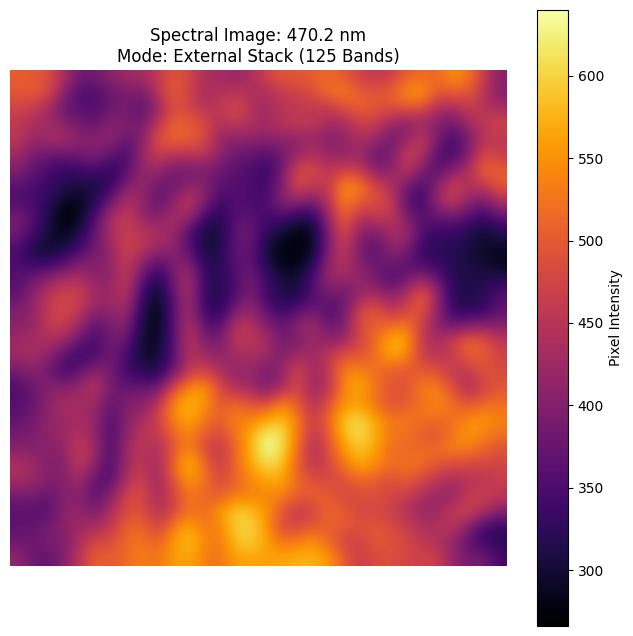

🔍 Wavelength 740.0nm correspond to channel index 72


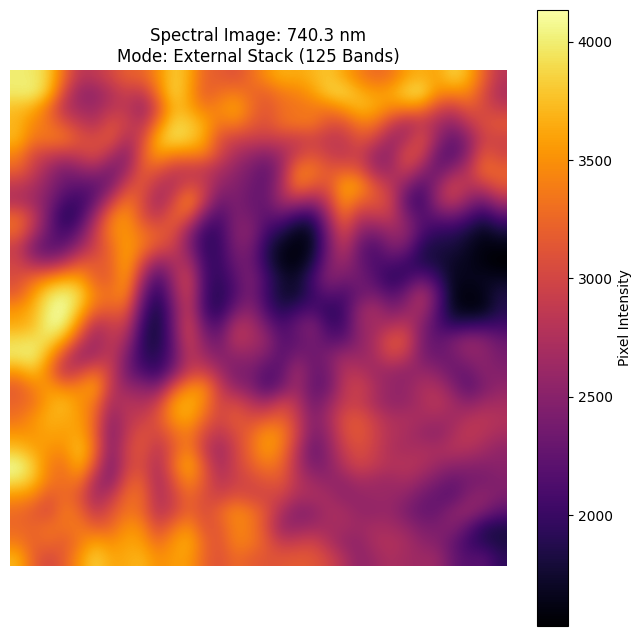

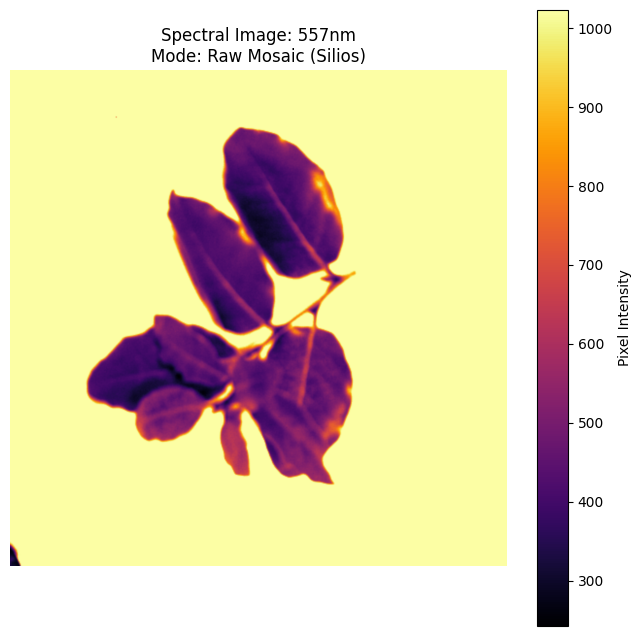

🔍 RGB Composé avec les canaux - R:5, G:3, B:1


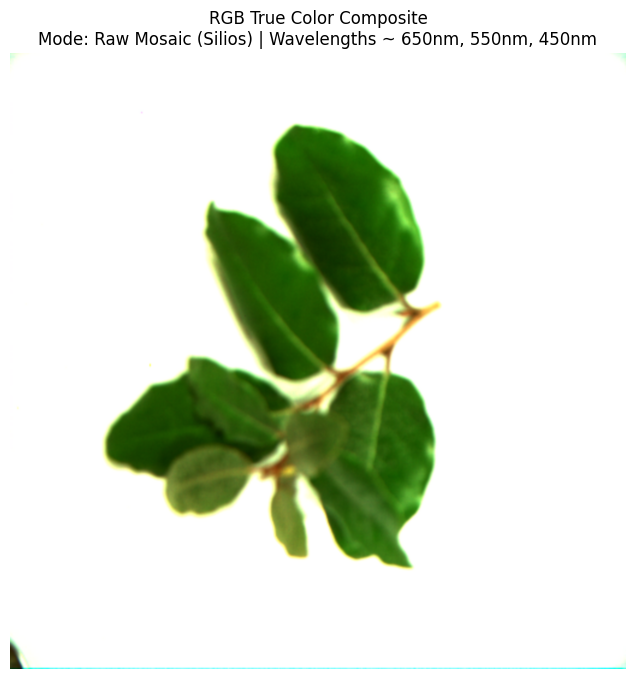

🔍 RGB Composé avec les canaux - R:50, G:25, B:0


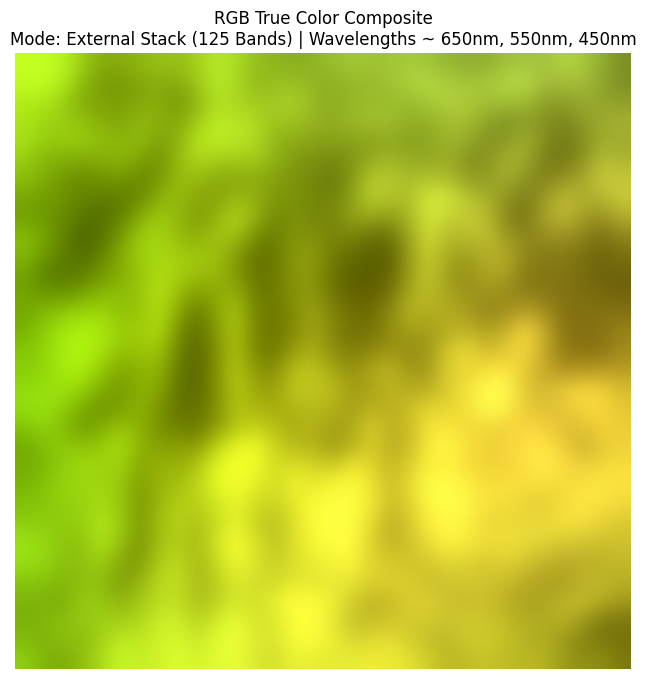

In [39]:
# Example 1: Show band by Index (0 = 410nm)
show_spectral_channel("C:/CROPSENSE/CROPSENSE_DATA/2026-03-18/rust/Spectral/Spectral_rust_4.tif", channel_index=5)
show_spectral_channel("C:/CROPSENSE/CROPSENSE_DATA/2026-03-18/rust/Spectral/Spectral_rust_4.tif", wavelength=740)

# Example 2: Show band by Wavelength (e.g., Red Edge 756nm)
show_spectral_channel("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", wavelength=557)
show_spectral_image("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff")
show_spectral_image("C:/CROPSENSE/CROPSENSE_DATA/2026-03-18/rust/Spectral/Spectral_rust_4.tif")

📊 Statistics for thermal_presample_00-08-09-074-thermo.tiff:
   🔹 Min: 19451.00
   🔸 Max: 26366.00
   sz Mean: 22738.63


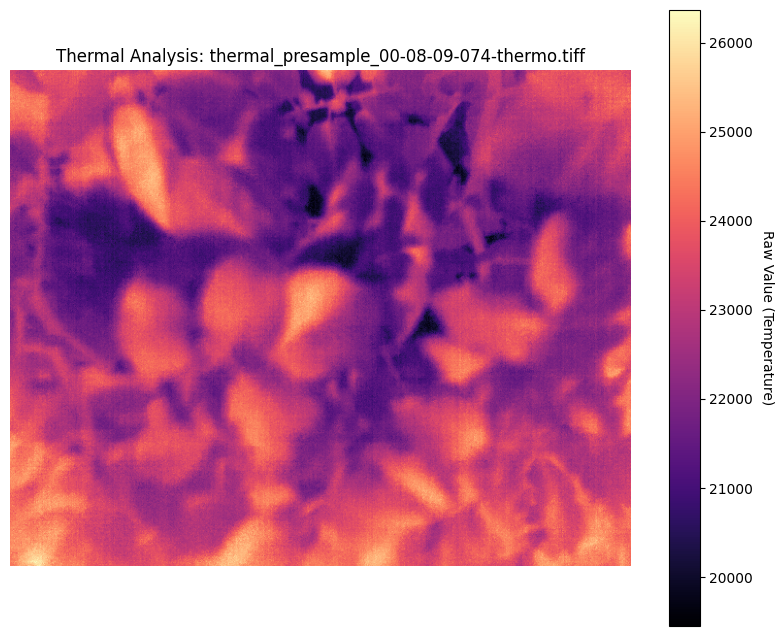

📊 Statistics for thermal_presample_00-08-09-074-cwsi.tiff:
   🔹 Min: 1904.00
   🔸 Max: 5070.00
   sz Mean: 3409.06


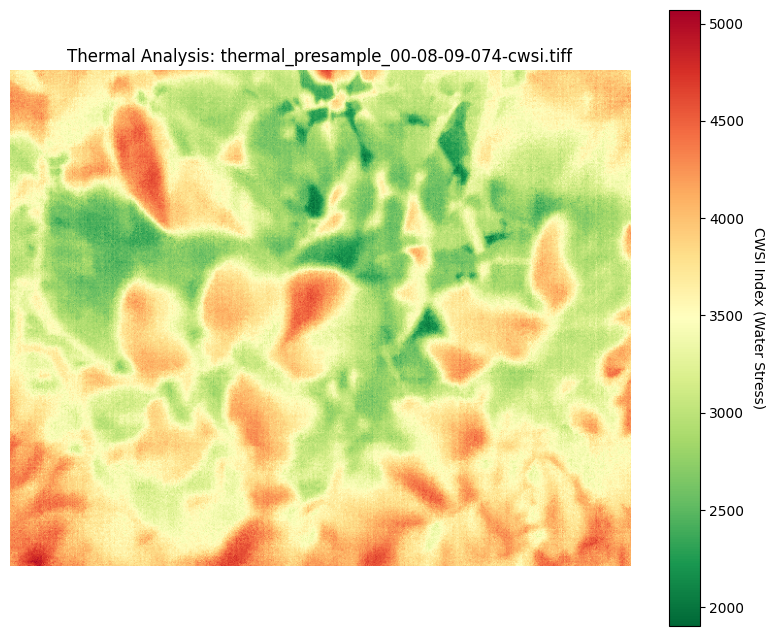

In [40]:
# --- EXAMPLE: Plot a thermic image file ---
# This will show the temperature and the water stress.
show_thermal_image("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/PreSample/Thermal/Thermal_PreSample_00-08-09-074-thermo.tiff")
show_thermal_image("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/PreSample/Thermal/Thermal_PreSample_00-08-09-074-cwsi.tiff")

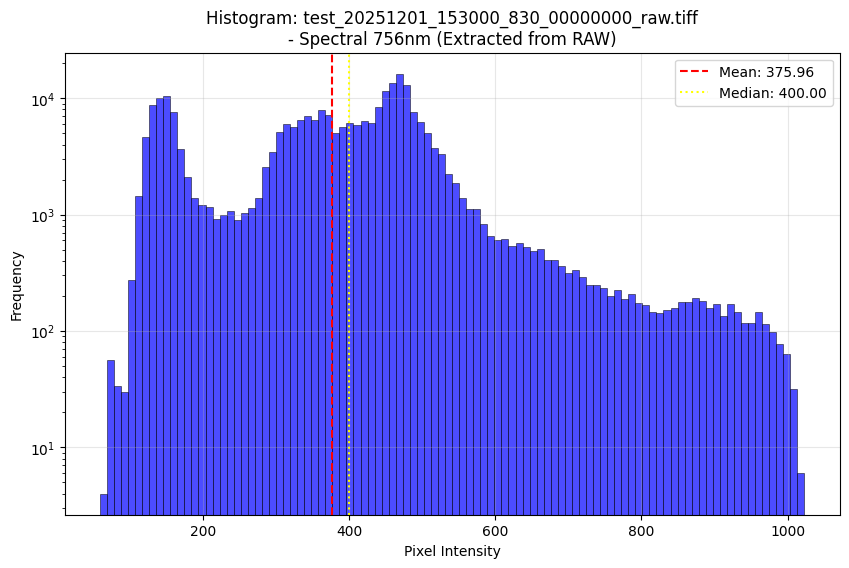

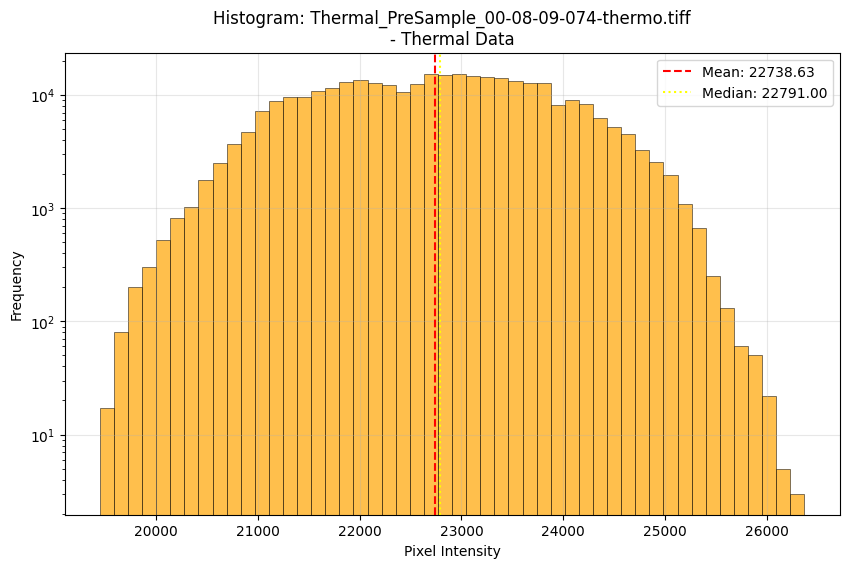

In [41]:
# --- EXAMPLE 1: Check the "Red Edge" band (Index 7) of a multispectral file ---
# This helps you see if the specific band used for NDVI is well exposed.
spectral_file = "C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff"
plot_image_histogram(spectral_file, band_index=7, bins=100, log_scale=True)

# --- EXAMPLE 2: Check a Thermal Temperature Map ---
# This shows the distribution of temperatures (e.g., most pixels are around 22°C).
thermal_file = "C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/PreSample/Thermal/Thermal_PreSample_00-08-09-074-thermo.tiff"
plot_image_histogram(thermal_file, bins=50, log_scale=True)

O

📊 Plotting Global Raw Histogram.


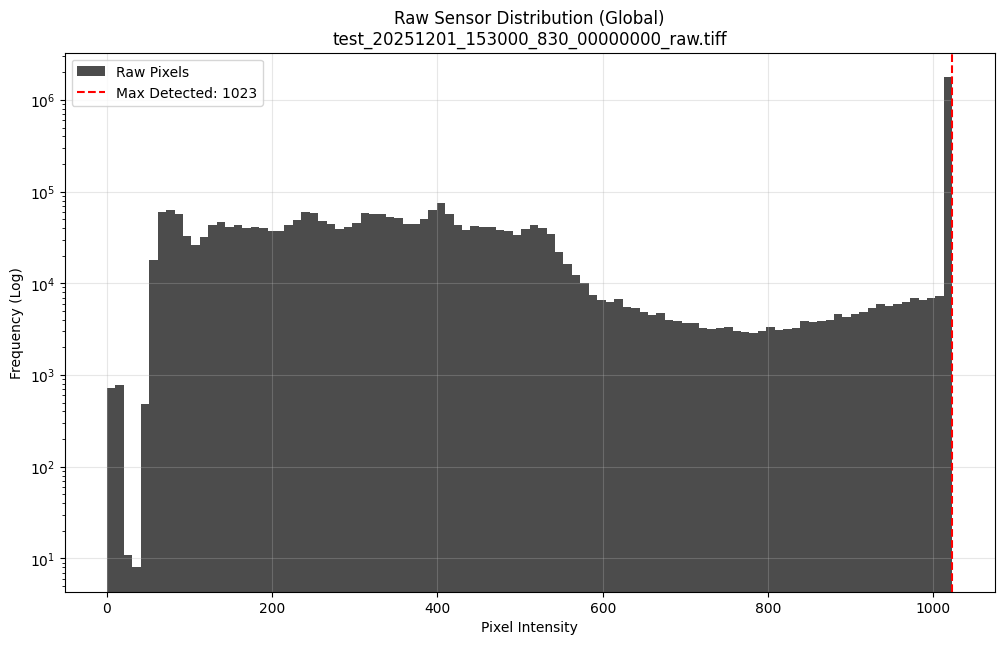

📊 Plotting Global Raw Histogram.


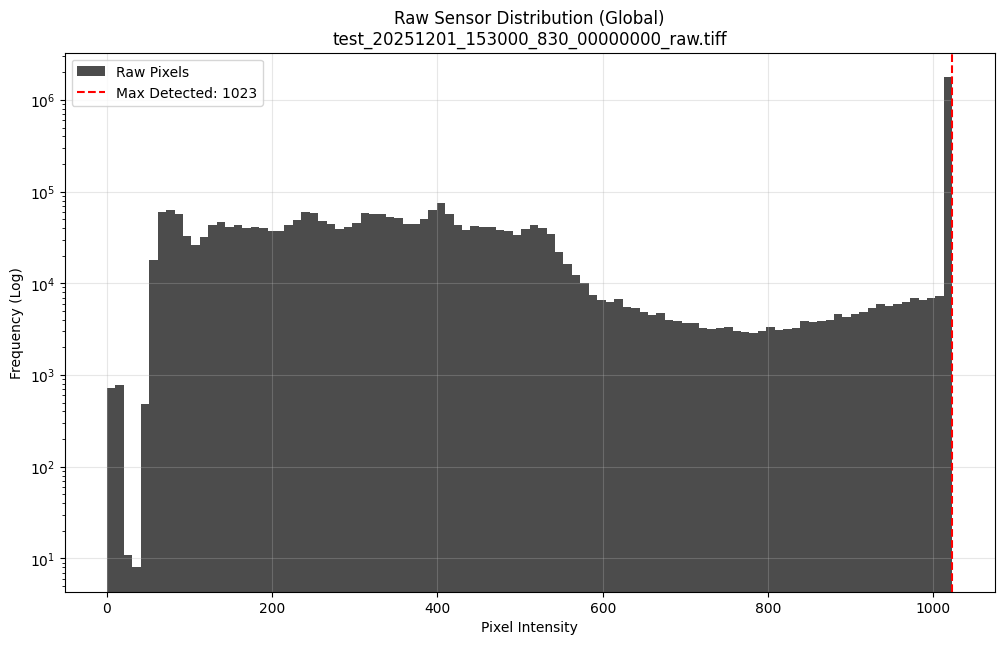

In [42]:

# --- EXAMPLE 1: Overlay Mode (Recommended) ---
# Draws 10 colored lines. Perfect to see if ONE specific band is dead or saturated.
plot_full_spectral_histogram("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", mode='overlay', log_scale=True)

# --- EXAMPLE 2: Global Mode ---
# Aggregates everything. Good to see the overall brightness of the image.
plot_full_spectral_histogram("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", mode='global', log_scale=True)

In [43]:
hyperspectral_data = prepare_hyperspectral_data("C:/CROPSENSE/CROPSENSE_DATA/2026-04-09/TestBatch/Spectral/Spectral_TestBatch_001.hdr", "C:/CROPSENSE/CROPSENSE_DATA/2026-04-09/TestBatch/Spectral/Spectral_TestBatch_DARKREF_001.hdr", "C:/CROPSENSE/CROPSENSE_DATA/2026-04-09/TestBatch/Spectral/Spectral_TestBatch_WHITEREF_001.hdr", 'purple', 0.07, 0.72, 0.01)
sick_plant, healthy_plant = separate_data(hyperspectral_data, ligne_coupe=800)

⏳ [1/4] Chargement des références (Optimisation RAM)...
⏳ [2/4] Chargement du fichier RAW et Calibration In-Place...
🌿 [3/4] Création du masque...
📊 [4/4] Extraction des signatures et Préparation visuelle...
✅ Données prêtes !
✂️ Découpage du cube à la ligne 800...
✅ Découpage terminé ! Deux sets de données créés.


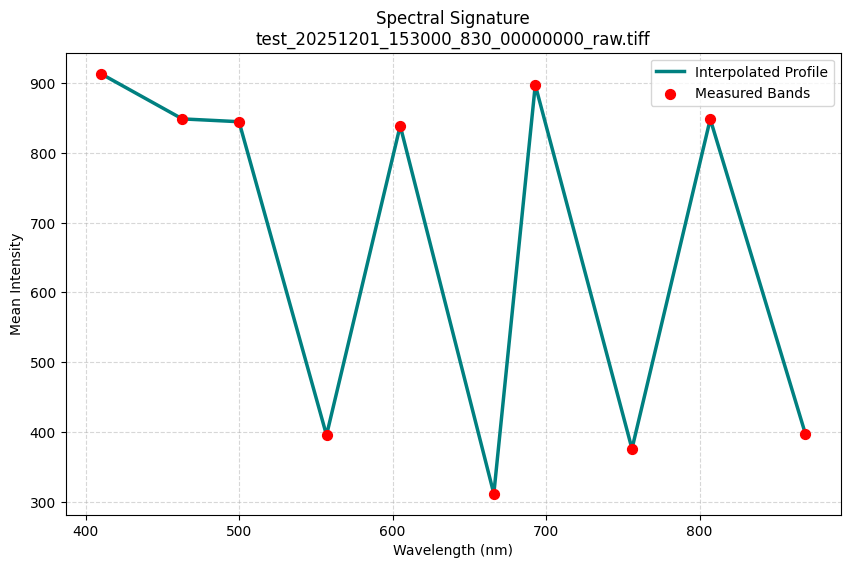

In [44]:
plot_spectral_profile("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", smooth=False)

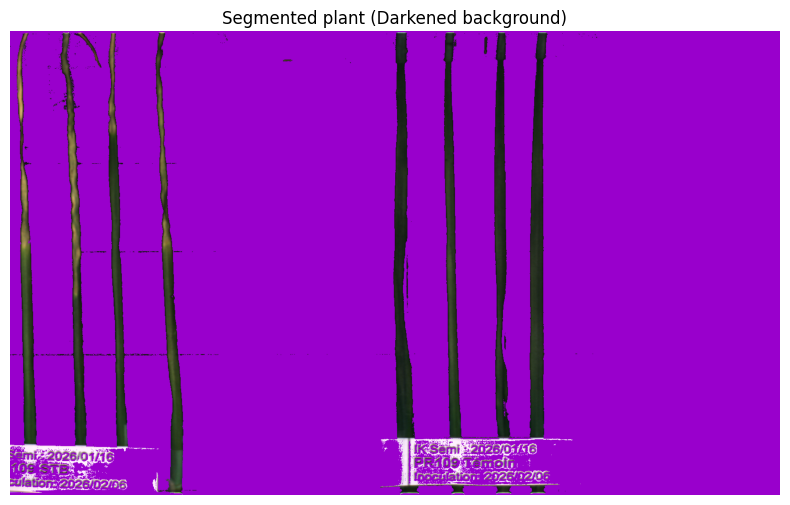

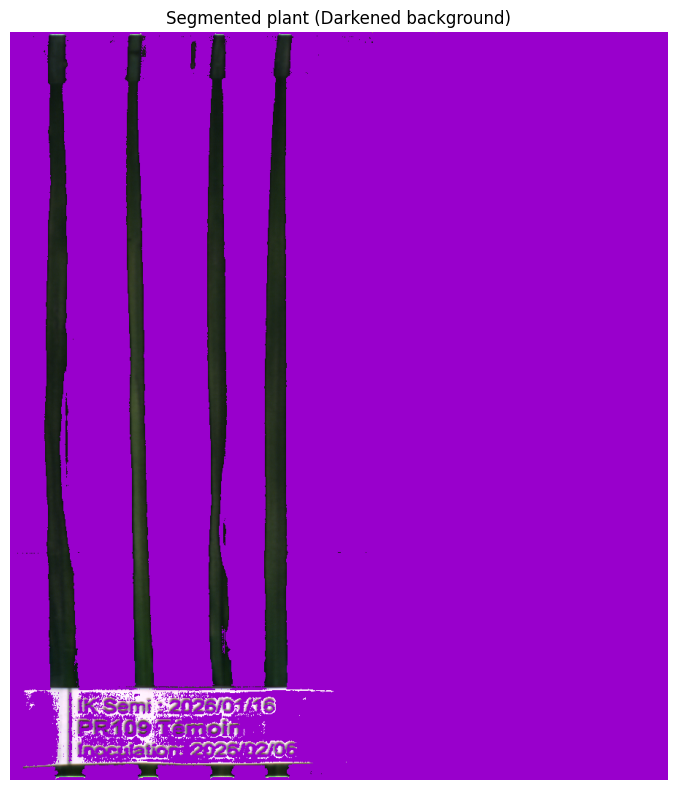

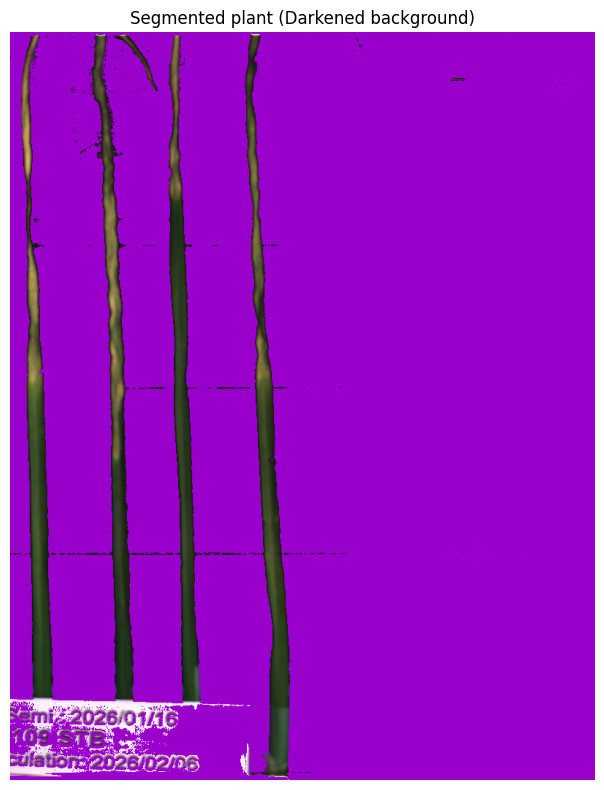

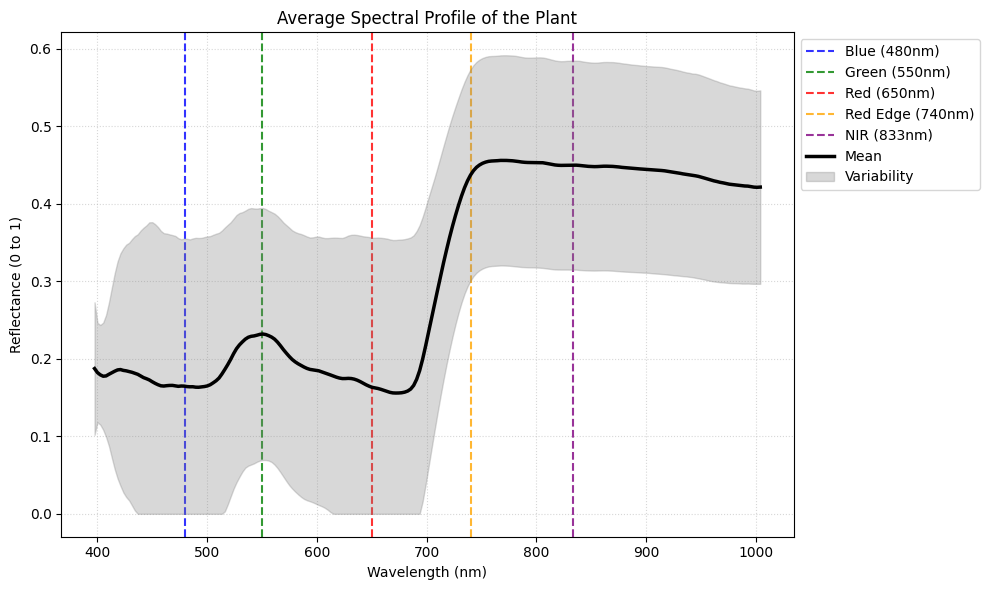

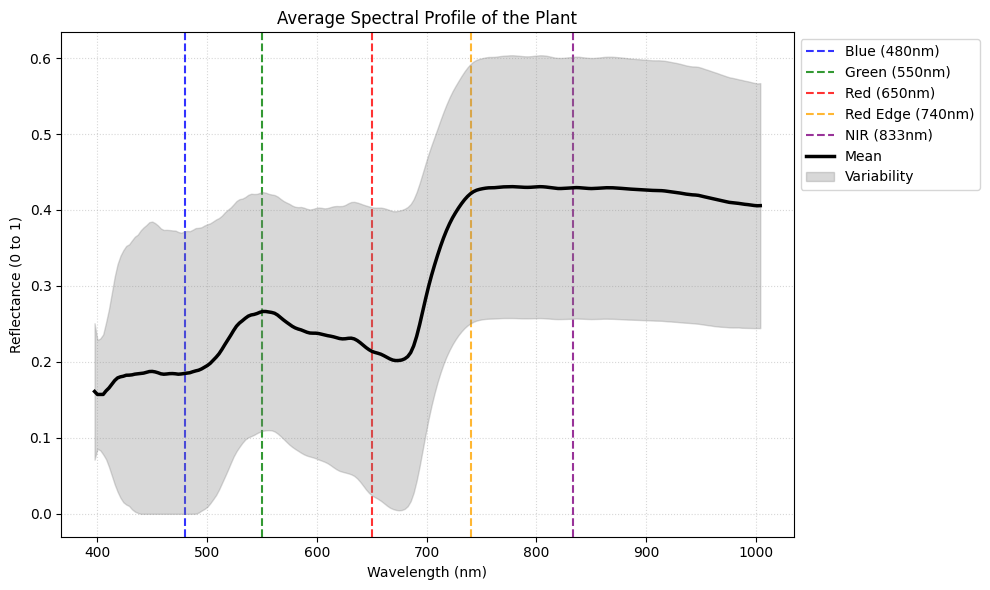

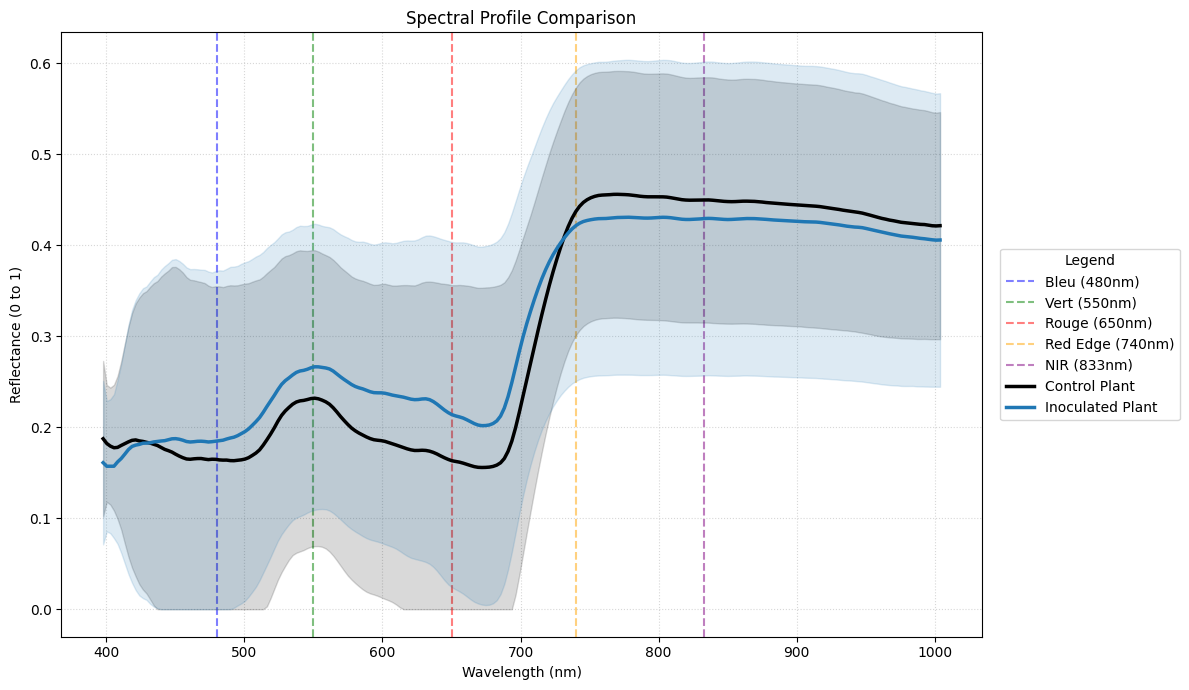

📊 Calcul NDVI (800/670) -> Bandes utilisées : 150 et 102
🌱 NVDI Formule Rayhana : 0.51048
📊 Calcul NDVI (800/680) -> Bandes utilisées : 150 et 106
🌱 NVDI Formule Yu : 0.50822
📊 Calcul GNDVI (800/550) -> Bandes utilisées : 150 et 58
🌱 GNVDI : 0.31020
📊 Calcul RVI (800/670) -> Bandes utilisées : 150 et 102
🌱 RVI : 2.50064
📊 Calcul WI (900/970) -> Bandes utilisées : 186 et 211
🌱 WI : 1.03833
📊 Calcul NDWI (900/970) -> Bandes utilisées : 186 et 211
🌱 NDWI : 0.01822
📊 Calcul SIPI (445/680/800) -> Bandes utilisées : 18, 106 et 150
🌱 SIPI : 0.99484
📊 Calcul PRI (531/570/) -> Bandes utilisées : 51 et 65
🌱 PRI : -0.01300
📊 Calcul ARI (510/700/) -> Bandes utilisées : 43 et 113
🌱 ARI : 1.17555
📊 Calcul ARI (510/550/) -> Bandes utilisées : 43 et 58
🌱 CARI : 2.87300
📊 Calcul NDVI (800/670) -> Bandes utilisées : 150 et 102
📊 Calcul GNDVI (800/550) -> Bandes utilisées : 150 et 58
📊 Calcul RVI (800/670) -> Bandes utilisées : 150 et 102
📊 Calcul WI (900/970) -> Bandes utilisées : 186 et 211
📊 Calcul ND

,Control Plant,Inoculated Plant
Health Indices,,
NDVI (800/670),0.58231,0.42452
GNDVI,0.36079,0.24967
RVI,2.90605,2.12684
WI,1.04077,1.03530
NDWI,0.01967,0.01649
SIPI,0.94147,1.07841
PRI,-0.02723,0.00402
ARI,1.08891,1.21597
CARI,3.53524,2.08058


In [45]:
show_hyperspectral_image(hyperspectral_data)
show_hyperspectral_image(healthy_plant)
show_hyperspectral_image(sick_plant)
show_hyperspectral_graph(healthy_plant)
show_hyperspectral_graph(sick_plant)
show_multiple_hyperspectral_graphs([healthy_plant, sick_plant], ["Control Plant", "Inoculated Plant"])
ndvi_rayhana = calculate_mean_ndvi(hyperspectral_data, cible_nir=800, cible_red=670)
print(f"🌱 NVDI Formule Rayhana : {ndvi_rayhana:.5f}")
ndvi_yu = calculate_mean_ndvi(hyperspectral_data, cible_nir=800, cible_red=680)
print(f"🌱 NVDI Formule Yu : {ndvi_yu:.5f}")
print(f"🌱 GNVDI : {calculate_mean_gndvi(hyperspectral_data):.5f}")
print(f"🌱 RVI : {calculate_mean_rvi(hyperspectral_data):.5f}")
print(f"🌱 WI : {calculate_mean_wi(hyperspectral_data):.5f}")
print(f"🌱 NDWI : {calculate_mean_ndwi(hyperspectral_data):.5f}")
print(f"🌱 SIPI : {calculate_mean_sipi(hyperspectral_data):.5f}")
print(f"🌱 PRI : {calculate_mean_pri(hyperspectral_data):.5f}")
print(f"🌱 ARI : {calculate_mean_ari(hyperspectral_data):.5f}")
print(f"🌱 CARI : {calculate_mean_cari(hyperspectral_data):.5f}")


tableau_comparatif = compare_plants_indices([healthy_plant, sick_plant], ["Control Plant", "Inoculated Plant"])



#explain_spectral_index("PRI")
explain_spectral_index("ALL")

# Affichage
tableau_comparatif

In [46]:
# --- EXAMPLE: Export data to a CSV file ---
# This will create a file named 'Analysis_P01.csv' in your current folder.
# You can then open this file in Excel to make your own custom graphs.
df = export_analysis_to_csv("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", output_csv="Analysis_P01_histogram.csv", analysis_type="histogram")


df = export_analysis_to_csv("C:/CROPSENSE/CROPSENSE_DATA/2025-12-10/test/Spectral/test_20251201_153000_830_00000000_raw.tiff", output_csv="Analysis_P01_profile.csv", analysis_type="profile")
# Optional: Print the first few rows to verify
print(df.head())

✅ Success! Data saved to: Analysis_P01_histogram.csv
✅ Success! Data saved to: Analysis_P01_profile.csv
   Wavelength_nm  Mean_Intensity
0            410      913.409790
1            463      848.694443
2            500      844.649254
3            557      395.507183
4            605      838.870342


In [47]:
# 1. Chargement brut (assurez-vous que le .hdr est bien redevenu 'bil')
chemin_raw = "C:/CROPSENSE/CROPSENSE_DATA/2026-03-04/TestBatch/Spectral/Spectral_TestBatch_001.hdr"
raw_cube = envi.open(chemin_raw).load()

# 2. Extraction des bandes RGB (sans même faire la calibration pour l'instant)
# On prend 3 bandes : Rouge (110), Vert (70), Bleu (30)
rgb_brut = raw_cube[:, :, [110, 70, 30]].astype(float)

# 3. NORMALISATION ROBUSTE (Le secret est ici !)
# On ignore les 2% des pixels les plus sombres et les 2% les plus clairs
min_val = np.percentile(rgb_brut, 2)
max_val = np.percentile(rgb_brut, 98)

# On force les pixels dans cette plage pour avoir un beau contraste
rgb_visuel = np.clip((rgb_brut - min_val) / (max_val - min_val), 0, 1)

rgb_final = np.rot90(rgb_visuel, k=1) 

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 1. Affichage "Photo" (Le 0,0 est en HAUT à gauche, standard en imagerie)
axes[0].imshow(rgb_final)
axes[0].set_title("Rotation propre (0,0 en haut à gauche)")

# 2. Affichage "Graphique Mathématique" (Le 0,0 est en BAS à gauche)
# L'argument origin='lower' force Matplotlib à mettre le zéro en bas.
axes[1].imshow(rgb_final, origin='lower')
axes[1].set_title("Rotation + 0,0 en bas à gauche")

plt.show()

FileNotFoundError: Unable to locate file "C:/CROPSENSE/CROPSENSE_DATA/2026-03-04/TestBatch/Spectral/Spectral_TestBatch_001.hdr". If the file exists, use its full path or place its directory in the SPECTRAL_DATA environment variable.

In [ ]:
import os
import spectral.io.envi as envi

hdr_path = "C:/CROPSENSE/CROPSENSE_DATA/2026-03-04/TestBatch/Spectral/Spectral_TestBatch_001.hdr"
raw_path = hdr_path.replace(".hdr", ".raw")

# S'il n'a pas l'extension .raw
if not os.path.exists(raw_path):
    raw_path = hdr_path.replace(".hdr", "")

# On lit l'entête
img = envi.open(hdr_path, image=raw_path)
taille_reelle_octets = os.path.getsize(raw_path)

# Une caméra FX10 (data type 12) enregistre 2 octets par pixel
# Taille d'une seule ligne = (colonnes * bandes * 2 octets)
taille_d_une_ligne = img.ncols * img.nbands * 2
lignes_reelles = taille_reelle_octets // taille_d_une_ligne

print(f"📄 Lignes réclamées par le .hdr : {img.nrows}")
print(f"📦 Lignes réellement présentes dans le .raw : {lignes_reelles}")

if img.nrows > lignes_reelles:
    print(f"\n❌ PROBLÈME DÉTECTÉ : Le fichier a été tronqué.")
    print(f"👉 SOLUTION : Ouvrez votre fichier .hdr avec le Bloc-notes, et modifiez 'lines = {img.nrows}' par 'lines = {lignes_reelles}'")
elif img.nrows == lignes_reelles:
    print(f"\n✅ Le fichier est parfait ! Le problème vient de la limite de mémoire (RAM) de Windows.")